# Chapter 2. Distribution Transport Before Flow Matching

This notebook is the paper-facing reproducibility notebook for Chapter 2. It expands the experiments cell by cell instead of delegating to a runner, so the data loading, cost construction, OT solution, path construction, energy computation, solver-in-loop proxy training, and artifact writing are all visible.

The chapter is intentionally limited to distribution transport before Flow Matching. Endpoint couplings are model-implied relations between snapshots, path constructions are illustrative bridges, the dynamic OT panel is a low-action energy proxy rather than a Benamou-Brenier solve, and the CNF section is a pedagogical solver-in-loop Neural ODE proxy rather than a full likelihood CNF benchmark.


## 1. Setup

This section fixes paths, random seed, plotting defaults, and the `quick_mode` setting used by the cloud reproducibility run. All figures are written to `figures/ch02`; all tables and the run summary are written to `outputs/ch02`.


In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mplconfig_ch02")
os.environ.setdefault("NUMBA_CACHE_DIR", "/tmp/numba_cache_ch02")

import json
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

started = time.perf_counter()
quick_mode = True
seed = 42
rng = np.random.default_rng(seed)

PROJECT_ROOT = Path.cwd().resolve()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents, PROJECT_ROOT / "flow_matching_for_dynamic_biology"]:
    if (candidate / "src").exists() and (candidate).exists():
        PROJECT_ROOT = candidate.resolve()
        break

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import load_eb_timecourse_for_ch03
from src.metrics import coupling_l1_distance, mmd_rbf
from src.models import VelocityMLP
from src.ot import (
    compute_ot_coupling_from_cost,
    coupling_diagnostics,
    independent_coupling,
    median_positive_scale,
    pairwise_squared_distances,
    sample_pair_indices_from_coupling,
)
from src.paths import curved_path, linear_path
from src.toy import make_y_branching_snapshots
from src.utils import ensure_dir, set_seed

set_seed(seed)

paper_root = ensure_dir(PROJECT_ROOT)
fig_dir = ensure_dir(paper_root / "figures" / "ch02")
out_dir = ensure_dir(paper_root / "outputs" / "ch02")
eb_path = PROJECT_ROOT / "data" / "trajectorynet_eb" / "eb_velocity_v5.npz"

print(f"PROJECT_ROOT={PROJECT_ROOT}")
print(f"quick_mode={quick_mode}, seed={seed}")
print(f"fig_dir={fig_dir.relative_to(PROJECT_ROOT)}")
print(f"out_dir={out_dir.relative_to(PROJECT_ROOT)}")


PROJECT_ROOT=/import/home4/xmabs/flow_matching_for_dynamic_biology/flow_matching_for_dynamic_biology
quick_mode=True, seed=42
fig_dir=figures/ch02
out_dir=outputs/ch02


In [2]:
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
import matplotlib.patches as patches
from IPython.display import Image, display

mpl.rcParams.update(
    {
        "font.size": 9,
        "axes.labelsize": 9,
        "axes.titlesize": 10,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "svg.fonttype": "none",
    }
)

source_time = "1"
target_time = "2"
n_source_ot = 250
n_target_ot = 250
max_cells_per_time = 900
cost_space = "PC-20"
visualization_space = "PHATE"
static_ot_main_epsilon = 0.05
sinkhorn_epsilons = [0.001, 0.01, 0.05, 0.1, 1.0, 5.0]

concept_boundaries = [
    "OT endpoint relation is model-implied, not observed lineage.",
    "Path energy is computed in PC-20.",
    "Dynamic OT panel is low-action intuition, not solved Benamou-Brenier.",
    "Solver-in-loop baseline is not full likelihood CNF.",
    "Chapter 2 stops at the CNF training bottleneck; Flow Matching training is deferred to Chapter 3.",
]
concept_boundaries


['OT endpoint relation is model-implied, not observed lineage.',
 'Path energy is computed in PC-20.',
 'Dynamic OT panel is low-action intuition, not solved Benamou-Brenier.',
 'Solver-in-loop baseline is not full likelihood CNF.',
 'Chapter 2 stops at the CNF training bottleneck; Flow Matching training is deferred to Chapter 3.']

In [3]:
from src.ch02_tutorial import (
    action_per_pair_pc,
    brownian_bridge_trajectories,
    build_expected_artifact_paths,
    coupling_diagnostic_row,
    display_path,
    draw_arrows,
    draw_endpoint_cloud,
    draw_fixed_endpoint_pairs_panel,
    energy_and_length_pc,
    euler_integrate_torch,
    path_stats,
    sample_gaussian_mixture_torch,
    save_ch02_table,
    save_fig_both,
    show_saved_png,
    sorted_time_labels,
    subsample_indices,
    table_preview,
    torch_mmd_rbf,
    write_artifact_manifest,
)


**Helper Boundary.** Reusable drawing, path-statistic, artifact, and CNF-proxy helpers now live in `src.ch02_tutorial`; the notebook keeps the chapter-specific design choices and computations visible.


## 2. Load EB Data And Representation Roles

This experiment uses `data/trajectorynet_eb/eb_velocity_v5.npz`. The cost space is PC-20 because OT costs and energy proxies should be computed in a Euclidean feature space. PHATE is visualization only; it is not used to define transport cost.


In [4]:
eb = load_eb_timecourse_for_ch03(
    path=eb_path,
    cost_embedding="pcs",
    plot_embedding="phate",
    n_cost_dims=20,
    max_cells_per_time=max_cells_per_time,
    seed=seed,
)

X_pc20 = np.asarray(eb["X_cost"], dtype=float)
X_phate = np.asarray(eb["X_plot"], dtype=float)
time_labels = eb["time"].astype(str)
timepoints = sorted_time_labels(time_labels)

print(f"Loaded EB cells after per-time cap: {X_pc20.shape[0]}")
print(f"Cost matrix source: {eb_path.relative_to(PROJECT_ROOT)}")
print(f"Timepoints: {timepoints}")
eb["full_counts_by_time"].head()


Loaded EB cells after per-time cap: 4500
Cost matrix source: data/trajectorynet_eb/eb_velocity_v5.npz
Timepoints: ['0', '1', '2', '3', '4']


,source,cost_embedding,plot_embedding,n_cost_dims,time,n_cells
0,/import/home4/xmabs/flow_matching_for_dynamic_...,pcs,phate,20,0,2381
1,/import/home4/xmabs/flow_matching_for_dynamic_...,pcs,phate,20,1,4163
2,/import/home4/xmabs/flow_matching_for_dynamic_...,pcs,phate,20,2,3278
3,/import/home4/xmabs/flow_matching_for_dynamic_...,pcs,phate,20,3,3665
4,/import/home4/xmabs/flow_matching_for_dynamic_...,pcs,phate,20,4,3332


In [5]:
representation_roles = pd.DataFrame(
    [
        {
            "object": "X_pc20",
            "source_key": "pcs",
            "role": "OT cost construction and PC-20 energy proxy",
            "used_for_cost": True,
            "used_for_visualization": False,
            "shape": str(tuple(X_pc20.shape)),
        },
        {
            "object": "X_phate",
            "source_key": "phate",
            "role": "2D plotting of EB snapshots and arrows",
            "used_for_cost": False,
            "used_for_visualization": True,
            "shape": str(tuple(X_phate.shape)),
        },
        {
            "object": "time_labels",
            "source_key": "sample_labels",
            "role": "empirical snapshot index",
            "used_for_cost": False,
            "used_for_visualization": True,
            "shape": str(tuple(time_labels.shape)),
        },
    ]
)
representation_roles


,object,source_key,role,used_for_cost,used_for_visualization,shape
0,X_pc20,pcs,OT cost construction and PC-20 energy proxy,True,False,"(4500, 20)"
1,X_phate,phate,2D plotting of EB snapshots and arrows,False,True,"(4500, 2)"
2,time_labels,sample_labels,empirical snapshot index,False,True,"(4500,)"


## 3. Static OT On EB Snapshots

Question: if we only observe two EB snapshot distributions at source time `1` and target time `2`, how different is an independent endpoint relation from a cost-aware OT endpoint relation?

We cap each timepoint at 900 cells during loading, then use 250 source cells and 250 target cells for OT. Costs are squared distances in PC-20. PHATE is used only to draw endpoint clouds and arrows.


In [6]:
idx0_all = np.flatnonzero(time_labels == source_time)
idx1_all = np.flatnonzero(time_labels == target_time)
if len(idx0_all) == 0 or len(idx1_all) == 0:
    raise ValueError(f"EB source/target times {source_time}->{target_time} were not found.")

idx0 = subsample_indices(idx0_all, n_source_ot, rng)
idx1 = subsample_indices(idx1_all, n_target_ot, rng)

X0_cost = X_pc20[idx0]
X1_cost = X_pc20[idx1]
X0_plot = X_phate[idx0]
X1_plot = X_phate[idx1]

pd.DataFrame(
    [
        {"time": source_time, "available_after_cap": len(idx0_all), "used_for_ot": len(idx0)},
        {"time": target_time, "available_after_cap": len(idx1_all), "used_for_ot": len(idx1)},
    ]
)


,time,available_after_cap,used_for_ot
0,1,900,250
1,2,900,250


In [7]:
C_raw = pairwise_squared_distances(X0_cost, X1_cost)
cost_scale = median_positive_scale(C_raw)
C_norm = C_raw / max(cost_scale, 1e-12)

pd.DataFrame(
    [
        {
            "cost_space": cost_space,
            "C_raw_shape": str(tuple(C_raw.shape)),
            "cost_scale": cost_scale,
            "C_raw_min": float(C_raw.min()),
            "C_raw_median": float(np.median(C_raw)),
            "C_raw_max": float(C_raw.max()),
        }
    ]
)


,cost_space,C_raw_shape,cost_scale,C_raw_min,C_raw_median,C_raw_max
0,PC-20,"(250, 250)",252.759349,16.413849,252.759349,1385.148398


In [8]:
pi_ind = independent_coupling(len(X0_cost), len(X1_cost))
plans = {}
sinkhorn_infos = {}
coupling_rows = [
    coupling_diagnostic_row("independent", None, pi_ind, C_raw, C_norm, None, cost_scale)
]

for epsilon in sinkhorn_epsilons:
    pi, info = compute_ot_coupling_from_cost(
        C_norm,
        epsilon=float(epsilon),
        return_info=True,
        num_iter_max=5000,
        stop_thr=1e-9,
    )
    plans[float(epsilon)] = pi
    sinkhorn_infos[float(epsilon)] = info
    coupling_rows.append(coupling_diagnostic_row("sinkhorn_ot", epsilon, pi, C_raw, C_norm, info, cost_scale))

pi_main = plans[static_ot_main_epsilon]
coupling_table = pd.DataFrame(coupling_rows)
coupling_table


,method,epsilon,expected_cost_raw,expected_cost_normalized,entropy,effective_support,row_l1_error,col_l1_error,sinkhorn_converged,sinkhorn_n_iter,sinkhorn_backend,cost_scale
0,independent,NaN,299.604267,1.185334,11.042922,62500.000000,6.505213e-16,1.951564e-15,NaN,NaN,independent,252.759349
1,sinkhorn_ot,0.001,182.493993,0.722007,6.466120,642.984328,1.198533e-04,1.092876e-16,False,5000.0,scaling_fallback,252.759349
2,sinkhorn_ot,0.010,147.956585,0.585365,6.349275,572.078003,1.309716e-16,6.034569e-06,False,4999.0,pot,252.759349
3,sinkhorn_ot,0.050,161.363085,0.638406,8.256609,3853.005684,1.249001e-16,1.401640e-09,True,190.0,pot,252.759349
4,sinkhorn_ot,0.100,182.410027,0.721675,9.415359,12275.478591,9.540979e-17,5.979862e-10,True,60.0,pot,252.759349
5,sinkhorn_ot,1.000,277.714295,1.098730,10.999203,59826.430303,1.040834e-16,3.807718e-16,True,10.0,pot,252.759349
6,sinkhorn_ot,5.000,295.370632,1.168584,11.041239,62394.880953,7.719519e-17,3.504141e-16,True,10.0,pot,252.759349


In [9]:
table02_01_path = save_ch02_table(coupling_table, out_dir, "table02_01_coupling_diagnostics.csv", paper_root)
table_preview(coupling_table, columns=["method", "epsilon", "expected_cost_raw", "effective_support", "sinkhorn_converged"], n=8)


,method,epsilon,expected_cost_raw,effective_support,sinkhorn_converged
0,independent,NaN,299.604267,62500.000000,NaN
1,sinkhorn_ot,0.001,182.493993,642.984328,False
2,sinkhorn_ot,0.010,147.956585,572.078003,False
3,sinkhorn_ot,0.050,161.363085,3853.005684,True
4,sinkhorn_ot,0.100,182.410027,12275.478591,True
5,sinkhorn_ot,1.000,277.714295,59826.430303,True
6,sinkhorn_ot,5.000,295.370632,62394.880953,True


In [10]:
i0_ind = rng.integers(0, len(X0_plot), size=32)
i1_ind = rng.integers(0, len(X1_plot), size=32)
i0_ot, i1_ot = sample_pair_indices_from_coupling(pi_main, batch_size=42, seed=seed + 10)
sampled_endpoint_pairs = pd.DataFrame(
    {
        "source_local_index": i0_ot,
        "target_local_index": i1_ot,
        "source_global_index": idx0[i0_ot],
        "target_global_index": idx1[i1_ot],
        "coupling": "sinkhorn_epsilon_0.05",
    }
)
sampled_endpoint_pairs.head()


,source_local_index,target_local_index,source_global_index,target_global_index,coupling
0,153,249,1427,2697,sinkhorn_epsilon_0.05
1,143,119,1404,2268,sinkhorn_epsilon_0.05
2,129,231,1358,2628,sinkhorn_epsilon_0.05
3,1,160,917,2400,sinkhorn_epsilon_0.05
4,137,211,1385,2560,sinkhorn_epsilon_0.05


**Panel Output.** The static OT diagnostics are saved one panel at a time so each notebook output is readable on its own.


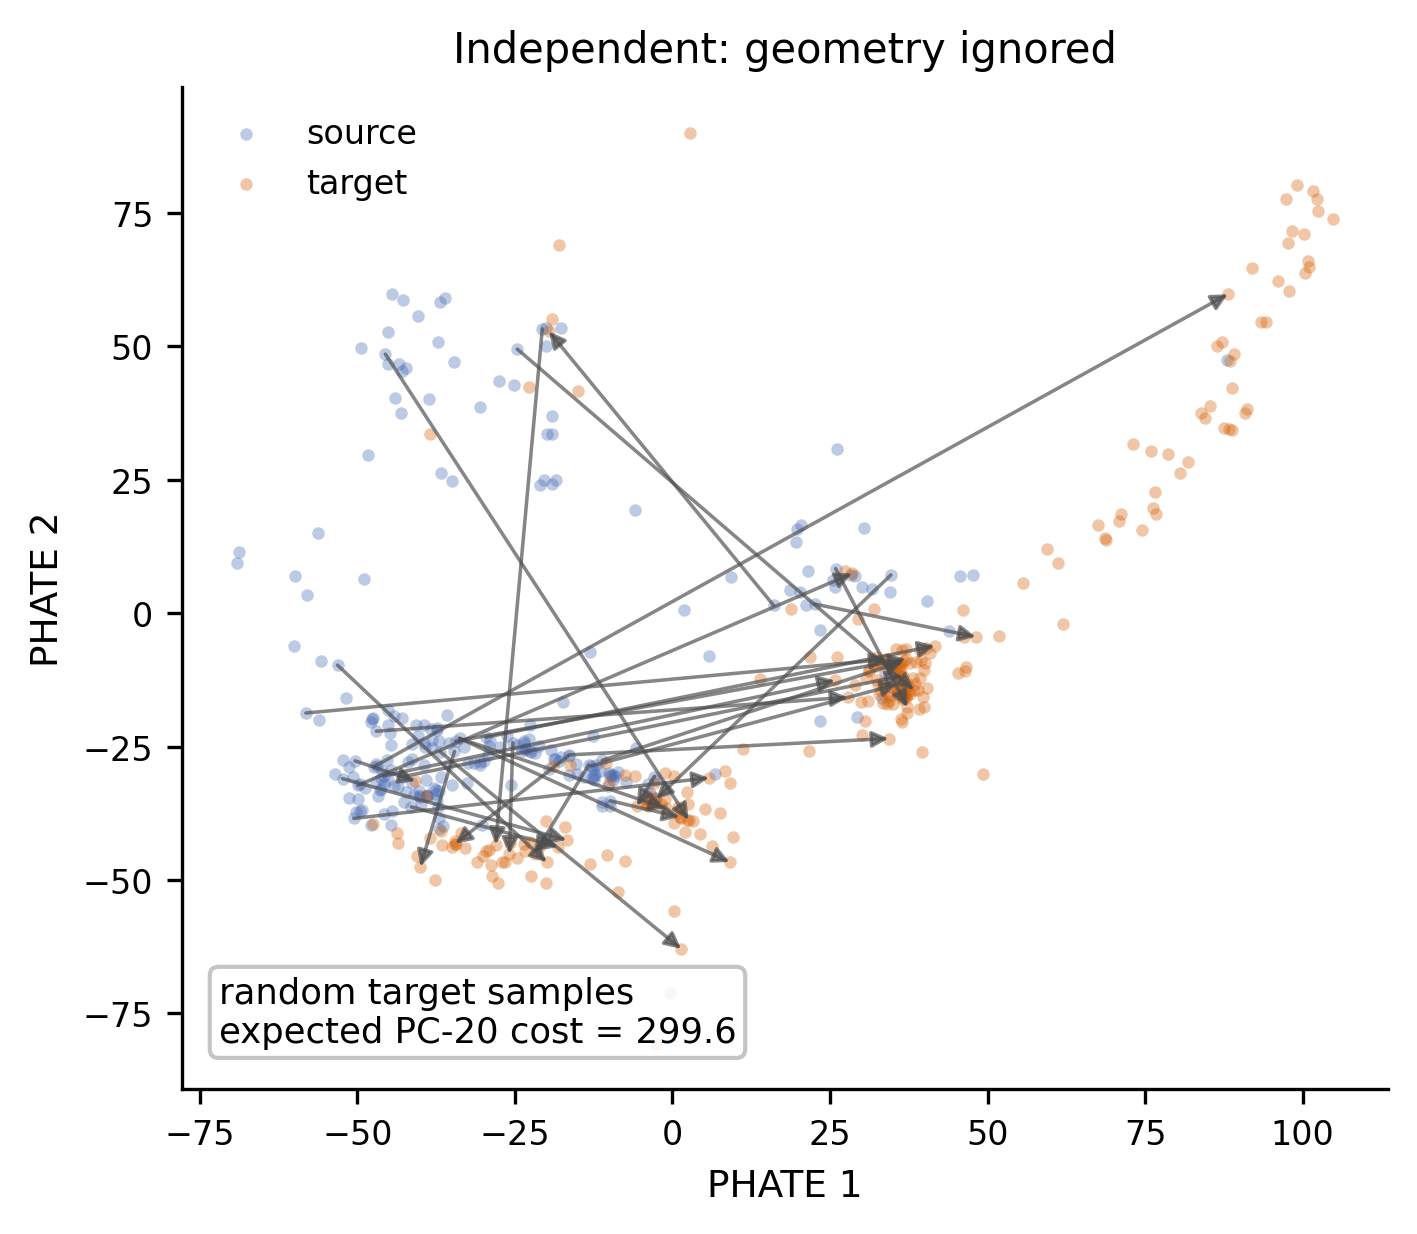

['figures/ch02/fig02_02a_static_ot_independent_endpoint_coupling.png',
 'figures/ch02/fig02_02a_static_ot_independent_endpoint_coupling.svg']

In [11]:
independent_expected_cost = float(coupling_table.loc[coupling_table["method"] == "independent", "expected_cost_raw"].iloc[0])

fig, ax = plt.subplots(figsize=(4.8, 4.2))
draw_endpoint_cloud(ax, X0_plot, X1_plot)
draw_arrows(ax, X0_plot, X1_plot, i0_ind, i1_ind, color="#4D4D4D", alpha=0.68, linewidth=0.85, mutation_scale=8.0)
ax.set_title("Independent: geometry ignored")
ax.set_xlabel("PHATE 1")
ax.set_ylabel("PHATE 2")
ax.legend(frameon=False, loc="best")
ax.text(
    0.03, 0.04,
    f"random target samples\nexpected PC-20 cost = {independent_expected_cost:.1f}",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=8.5,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="#BBBBBB", alpha=0.86),
)
fig.tight_layout()
fig02_02a_paths = save_fig_both(fig, fig_dir, "fig02_02a_static_ot_independent_endpoint_coupling", paper_root)
show_saved_png(fig_dir, "fig02_02a_static_ot_independent_endpoint_coupling")
fig02_02a_paths


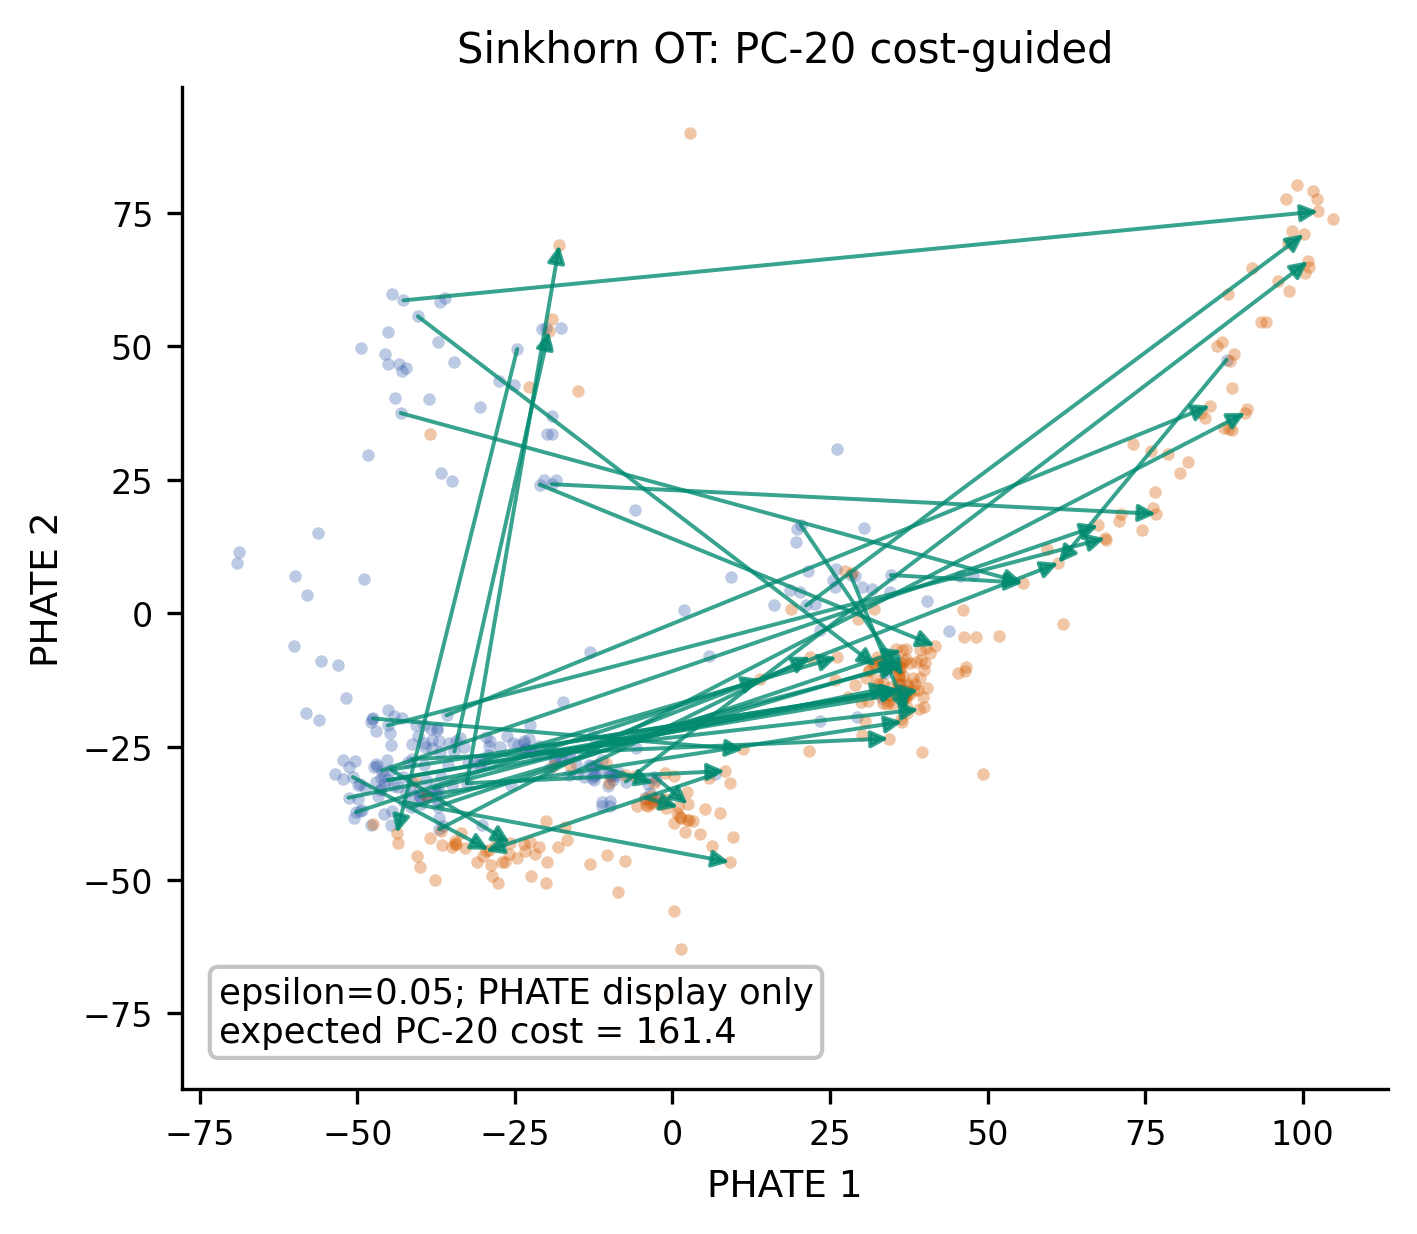

['figures/ch02/fig02_02b_static_ot_sinkhorn_endpoint_coupling.png',
 'figures/ch02/fig02_02b_static_ot_sinkhorn_endpoint_coupling.svg']

In [12]:
main_row_for_panel = coupling_table[(coupling_table["method"] == "sinkhorn_ot") & np.isclose(coupling_table["epsilon"], static_ot_main_epsilon)].iloc[0]
main_expected_cost = float(main_row_for_panel["expected_cost_raw"])

fig, ax = plt.subplots(figsize=(4.8, 4.2))
draw_endpoint_cloud(ax, X0_plot, X1_plot)
draw_arrows(ax, X0_plot, X1_plot, i0_ot, i1_ot, color="#008A70", alpha=0.78, linewidth=0.95, mutation_scale=8.5)
ax.set_title("Sinkhorn OT: PC-20 cost-guided")
ax.set_xlabel("PHATE 1")
ax.set_ylabel("PHATE 2")
ax.text(
    0.03, 0.04,
    f"epsilon={static_ot_main_epsilon}; PHATE display only\nexpected PC-20 cost = {main_expected_cost:.1f}",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=8.5,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="#BBBBBB", alpha=0.86),
)
fig.tight_layout()
fig02_02b_paths = save_fig_both(fig, fig_dir, "fig02_02b_static_ot_sinkhorn_endpoint_coupling", paper_root)
show_saved_png(fig_dir, "fig02_02b_static_ot_sinkhorn_endpoint_coupling")
fig02_02b_paths


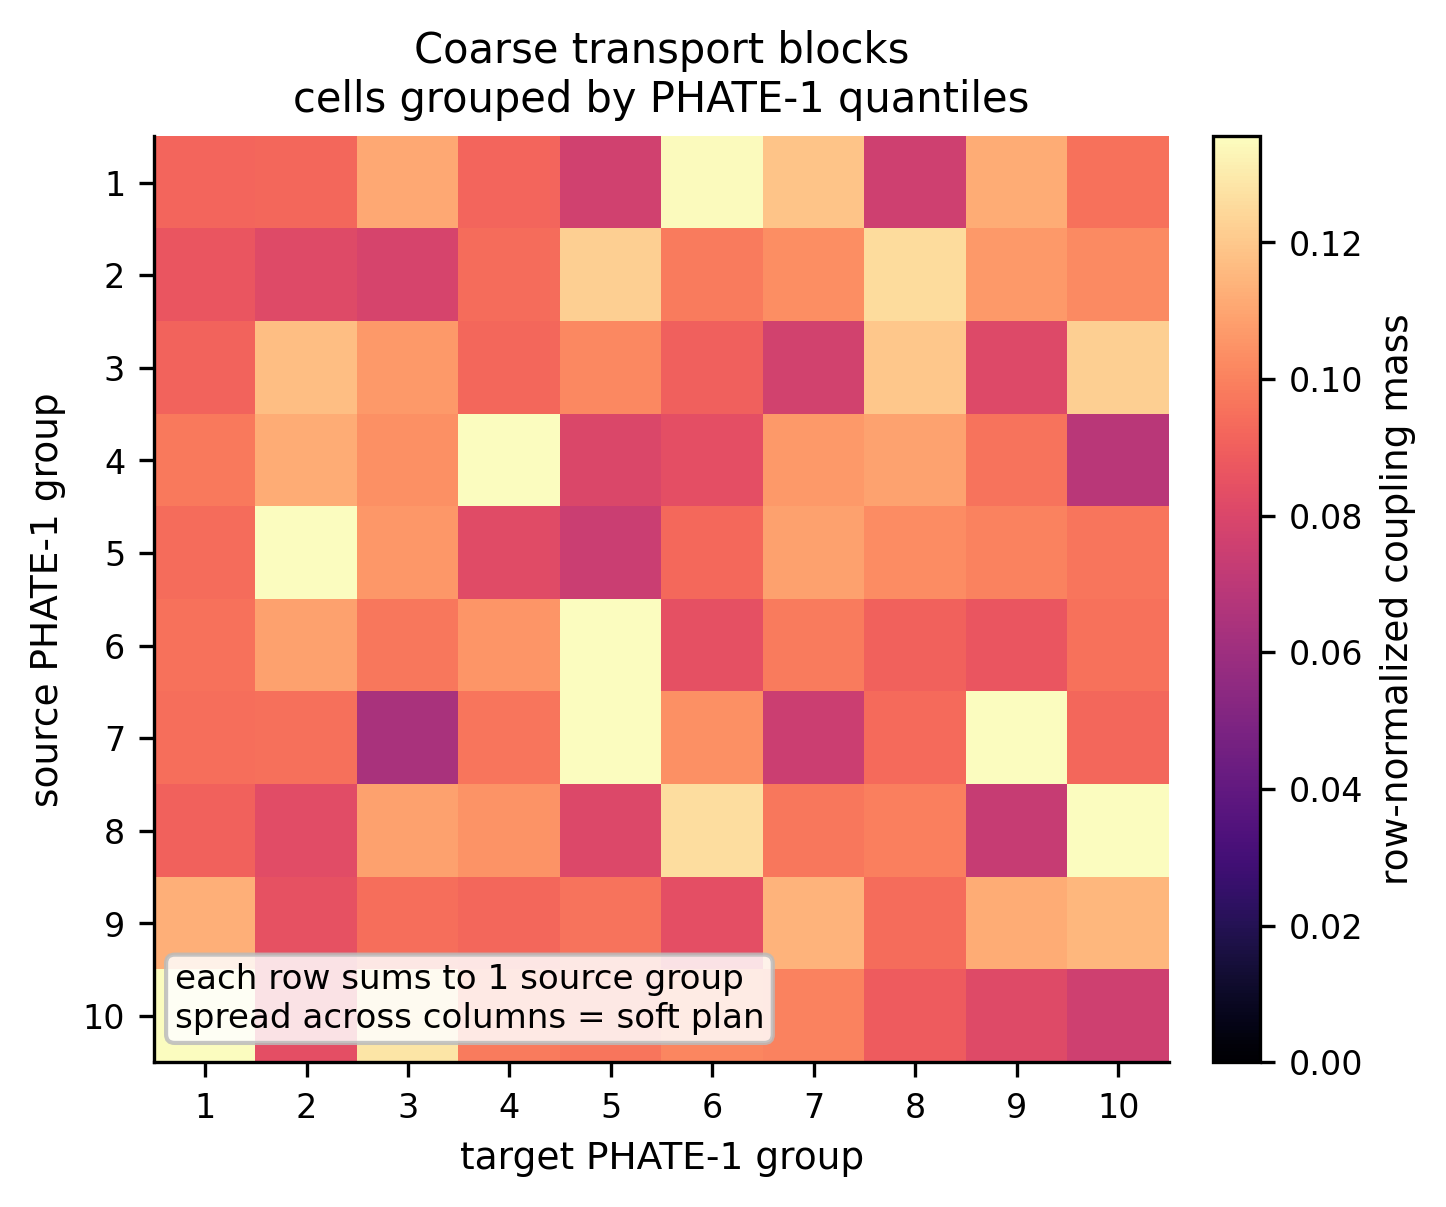

['figures/ch02/fig02_02c_static_ot_transport_plan_heatmap.png',
 'figures/ch02/fig02_02c_static_ot_transport_plan_heatmap.svg']

In [13]:
n_transport_bins = 10
source_bins = np.clip(
    np.searchsorted(np.quantile(X0_plot[:, 0], np.linspace(0, 1, n_transport_bins + 1))[1:-1], X0_plot[:, 0], side="right"),
    0,
    n_transport_bins - 1,
)
target_bins = np.clip(
    np.searchsorted(np.quantile(X1_plot[:, 0], np.linspace(0, 1, n_transport_bins + 1))[1:-1], X1_plot[:, 0], side="right"),
    0,
    n_transport_bins - 1,
)
source_membership = np.eye(n_transport_bins)[source_bins]
target_membership = np.eye(n_transport_bins)[target_bins]
coarse_pi = source_membership.T @ pi_main @ target_membership
row_sums = coarse_pi.sum(axis=1, keepdims=True)
row_normalized_coarse_pi = np.divide(coarse_pi, row_sums, out=np.zeros_like(coarse_pi), where=row_sums > 0)
color_max = max(0.12, float(np.quantile(row_normalized_coarse_pi, 0.95)))

fig, ax = plt.subplots(figsize=(4.9, 4.1))
im = ax.imshow(row_normalized_coarse_pi, aspect="auto", cmap="magma", vmin=0.0, vmax=color_max)
ticks = np.arange(n_transport_bins)
ax.set_xticks(ticks, ticks + 1)
ax.set_yticks(ticks, ticks + 1)
ax.set_title("Coarse transport blocks\ncells grouped by PHATE-1 quantiles")
ax.set_xlabel("target PHATE-1 group")
ax.set_ylabel("source PHATE-1 group")
ax.text(
    0.02, 0.03,
    "each row sums to 1 source group\nspread across columns = soft plan",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=8.2,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="#BBBBBB", alpha=0.84),
)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="row-normalized coupling mass")
fig.tight_layout()
fig02_02c_paths = save_fig_both(fig, fig_dir, "fig02_02c_static_ot_transport_plan_heatmap", paper_root)
show_saved_png(fig_dir, "fig02_02c_static_ot_transport_plan_heatmap")
fig02_02c_paths


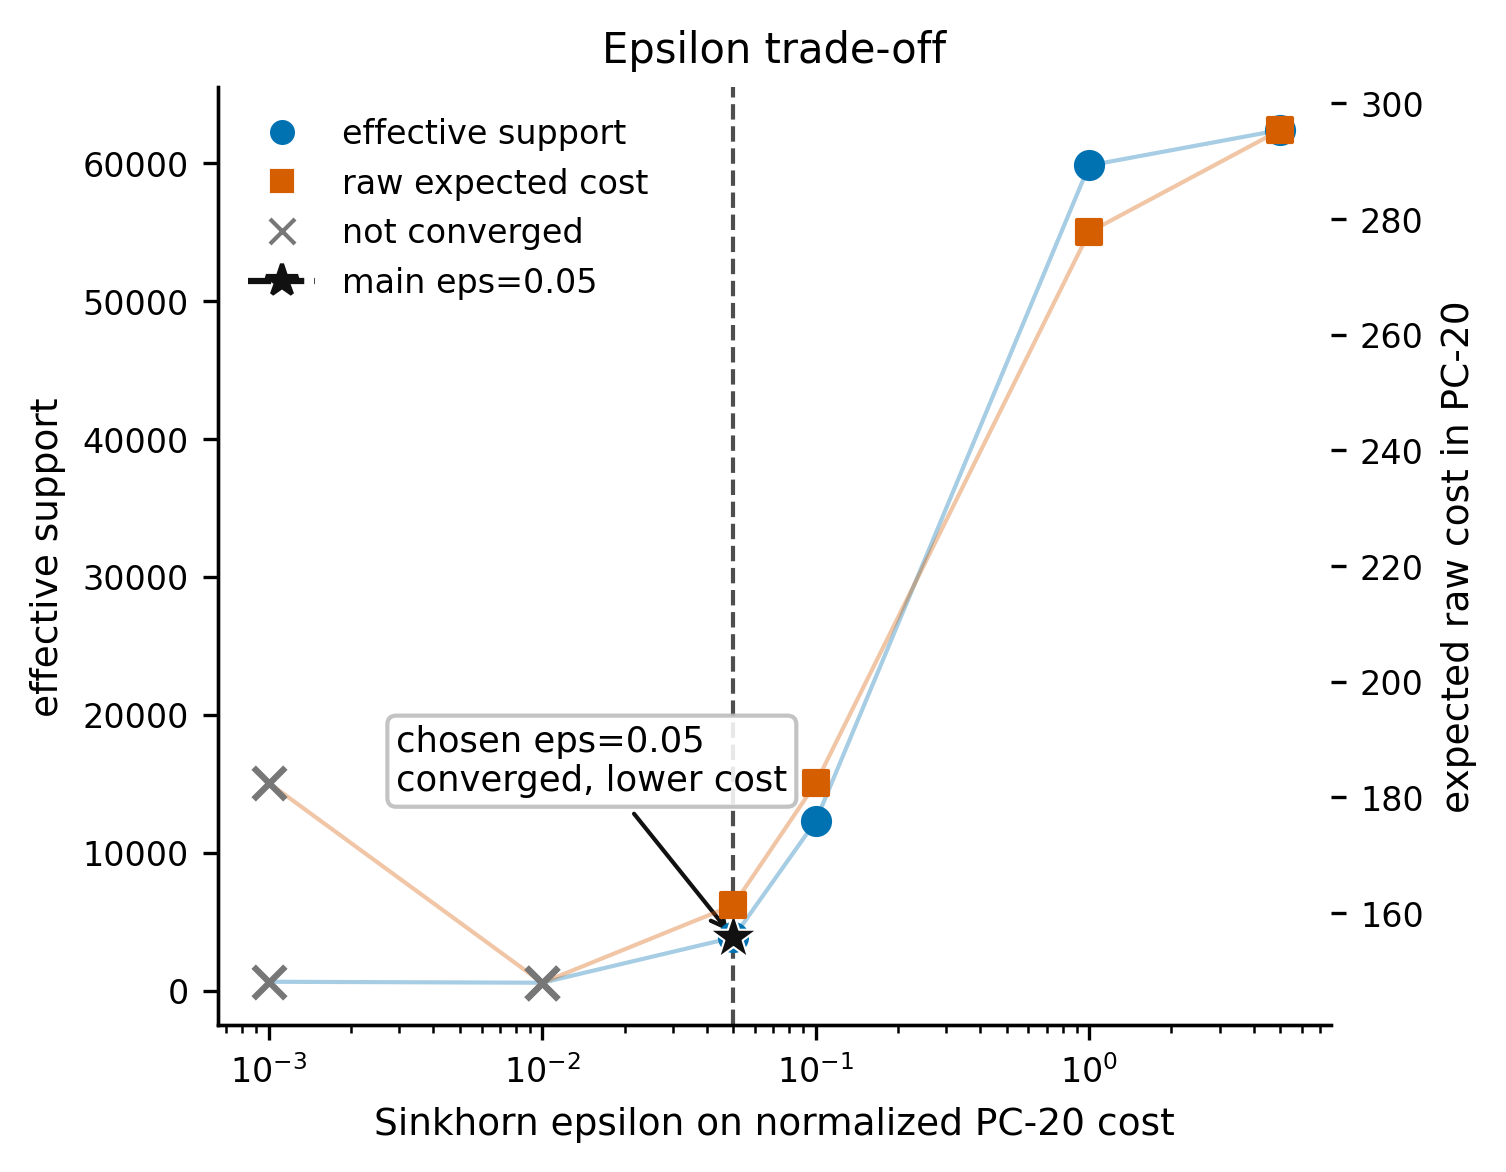

['figures/ch02/fig02_02d_static_ot_epsilon_sensitivity.png',
 'figures/ch02/fig02_02d_static_ot_epsilon_sensitivity.svg']

In [14]:
eps_df = coupling_table[coupling_table["method"] == "sinkhorn_ot"].copy()
converged = eps_df["sinkhorn_converged"].astype(bool).to_numpy()
eps_values = eps_df["epsilon"].to_numpy(dtype=float)
support_values = eps_df["effective_support"].to_numpy(dtype=float)
cost_values = eps_df["expected_cost_raw"].to_numpy(dtype=float)
main_row = eps_df[np.isclose(eps_df["epsilon"], static_ot_main_epsilon)].iloc[0]
independent_expected_cost = float(coupling_table.loc[coupling_table["method"] == "independent", "expected_cost_raw"].iloc[0])
main_expected_cost = float(main_row["expected_cost_raw"])

fig, ax = plt.subplots(figsize=(5.1, 4.0))
ax.plot(eps_values, support_values, color="#0072B2", alpha=0.35, linewidth=1.0)
ax.scatter(eps_values[converged], support_values[converged], marker="o", s=42, color="#0072B2", zorder=4)
ax.scatter(eps_values[~converged], support_values[~converged], marker="x", s=58, color="#777777", linewidths=1.5, zorder=5)
ax.set_xscale("log")
ax.set_xlabel("Sinkhorn epsilon on normalized PC-20 cost")
ax.set_ylabel("effective support")
ax.axvline(static_ot_main_epsilon, color="#222222", linestyle="--", linewidth=1.0, alpha=0.8)
ax.scatter([static_ot_main_epsilon], [float(main_row["effective_support"])], marker="*", s=145, color="#111111", edgecolors="white", linewidths=0.5, zorder=6)

ax2 = ax.twinx()
ax2.plot(eps_values, cost_values, color="#D55E00", alpha=0.35, linewidth=1.0)
ax2.scatter(eps_values[converged], cost_values[converged], marker="s", s=34, color="#D55E00", zorder=4)
ax2.scatter(eps_values[~converged], cost_values[~converged], marker="x", s=58, color="#777777", linewidths=1.5, zorder=5)
ax2.set_ylabel("expected raw cost in PC-20")
ax.set_title("Epsilon trade-off")
ax.legend(
    handles=[
        Line2D([0], [0], marker="o", color="#0072B2", linestyle="None", markersize=5, label="effective support"),
        Line2D([0], [0], marker="s", color="#D55E00", linestyle="None", markersize=5, label="raw expected cost"),
        Line2D([0], [0], marker="x", color="#777777", linestyle="None", markersize=6, label="not converged"),
        Line2D([0], [0], marker="*", color="#111111", linestyle="--", markersize=8, label="main eps=0.05"),
    ],
    frameon=False,
    loc="best",
)
ax.annotate(
    "chosen eps=0.05\nconverged, lower cost",
    xy=(static_ot_main_epsilon, float(main_row["effective_support"])),
    xytext=(0.16, 0.25),
    textcoords="axes fraction",
    arrowprops=dict(arrowstyle="->", color="#111111", lw=1.0),
    fontsize=8.5,
    ha="left",
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="#BBBBBB", alpha=0.88),
)
fig.tight_layout()
fig02_02d_paths = save_fig_both(fig, fig_dir, "fig02_02d_static_ot_epsilon_sensitivity", paper_root)
show_saved_png(fig_dir, "fig02_02d_static_ot_epsilon_sensitivity")
fig02_02d_paths


In [15]:
fig02_02_paths = fig02_02a_paths + fig02_02b_paths + fig02_02c_paths + fig02_02d_paths
fig02_02_paths


['figures/ch02/fig02_02a_static_ot_independent_endpoint_coupling.png',
 'figures/ch02/fig02_02a_static_ot_independent_endpoint_coupling.svg',
 'figures/ch02/fig02_02b_static_ot_sinkhorn_endpoint_coupling.png',
 'figures/ch02/fig02_02b_static_ot_sinkhorn_endpoint_coupling.svg',
 'figures/ch02/fig02_02c_static_ot_transport_plan_heatmap.png',
 'figures/ch02/fig02_02c_static_ot_transport_plan_heatmap.svg',
 'figures/ch02/fig02_02d_static_ot_epsilon_sensitivity.png',
 'figures/ch02/fig02_02d_static_ot_epsilon_sensitivity.svg']

**Claim Boundary.** Sinkhorn OT at ε=0.05 reduces expected PC-20 transport cost from 299.6 to 161.4, while concentrating mass relative to the independent coupling. Smaller ε may reduce cost further but did not converge in this run. PHATE is visualization only. The OT plan is a model-implied endpoint coupling, not observed lineage.


## 4. Optional OT Cost Sensitivity Across PC Dimensions

Question: does the endpoint plan materially change if the same EB snapshots are compared in PC-5, PC-10, PC-20, or PC-50? We recompute Sinkhorn OT at ε=0.05 and compare each plan to the PC-20 plan by L1 distance.


In [16]:
eb50 = load_eb_timecourse_for_ch03(
    path=eb_path,
    cost_embedding="pcs",
    plot_embedding="phate",
    n_cost_dims=50,
    max_cells_per_time=max_cells_per_time,
    seed=seed,
)
labels50 = eb50["time"].astype(str)
rng_sensitivity = np.random.default_rng(seed + 90)
idx0_sens = subsample_indices(np.flatnonzero(labels50 == source_time), n_source_ot, rng_sensitivity)
idx1_sens = subsample_indices(np.flatnonzero(labels50 == target_time), n_target_ot, rng_sensitivity)

pc_dim_values = [5, 10, 20, 50]
sensitivity_plans = {}
sensitivity_rows = []
for pc_dims in pc_dim_values:
    X0_dim = np.asarray(eb50["X_cost"][idx0_sens, :pc_dims], dtype=float)
    X1_dim = np.asarray(eb50["X_cost"][idx1_sens, :pc_dims], dtype=float)
    C_dim_raw = pairwise_squared_distances(X0_dim, X1_dim)
    scale_dim = median_positive_scale(C_dim_raw)
    C_dim_norm = C_dim_raw / max(scale_dim, 1e-12)
    pi_dim, info_dim = compute_ot_coupling_from_cost(C_dim_norm, epsilon=static_ot_main_epsilon, return_info=True)
    sensitivity_plans[int(pc_dims)] = pi_dim
    diag_dim = coupling_diagnostics(pi_dim, C_dim_raw)
    sensitivity_rows.append(
        {
            "pc_dims": int(pc_dims),
            "epsilon": static_ot_main_epsilon,
            "expected_cost_raw": diag_dim["expected_cost"],
            "entropy": diag_dim["entropy"],
            "effective_support": diag_dim["effective_support"],
            "row_l1_error": diag_dim["row_l1_error"],
            "col_l1_error": diag_dim["col_l1_error"],
            "sinkhorn_converged": bool(info_dim.get("sinkhorn_converged", False)),
            "sinkhorn_backend": str(info_dim.get("backend", "")),
            "cost_scale": float(scale_dim),
        }
    )

pc20_plan_for_sensitivity = sensitivity_plans[20]
for row in sensitivity_rows:
    row["l1_to_pc20_plan"] = coupling_l1_distance(sensitivity_plans[int(row["pc_dims"])], pc20_plan_for_sensitivity)

ot_cost_sensitivity_table = pd.DataFrame(sensitivity_rows)
table02_optional_path = save_ch02_table(ot_cost_sensitivity_table, out_dir, "table02_optional_ot_cost_sensitivity.csv", paper_root)
table_preview(ot_cost_sensitivity_table, columns=["pc_dims", "epsilon", "expected_cost_raw", "effective_support", "l1_to_pc20_plan"], n=8)


,pc_dims,epsilon,expected_cost_raw,effective_support,l1_to_pc20_plan
0,5,0.05,67.782844,4808.313063,1.302791
1,10,0.05,108.136977,3956.627337,0.813855
2,20,0.05,157.675060,4017.558193,0.000000
3,50,0.05,227.991956,4999.141525,0.572888


**Claim Boundary.** The sensitivity table changes only the feature dimension used for the static endpoint cost. It does not establish a unique biological pairing, and it does not change the chapter's main PC-20 convention.


## 5. Same Endpoints, Different Paths

Question: does an endpoint coupling determine a trajectory? We use a toy 2D branching snapshot system, sample the same endpoint pairs from an OT endpoint coupling, and draw three bridge families: straight, curved deterministic, and Brownian stochastic.


In [17]:
toy = make_y_branching_snapshots(
    n_cells=400,
    timepoints=(0.0, 1.0),
    rare_fate_fraction=0.5,
    noise=0.075,
    seed=seed,
)
toy_X = np.asarray(toy.X, dtype=float)
toy_times = np.asarray(toy.time, dtype=float)
toy_X0 = toy_X[np.isclose(toy_times, 0.0)]
toy_X1 = toy_X[np.isclose(toy_times, 1.0)]

toy_C_raw = pairwise_squared_distances(toy_X0, toy_X1)
toy_C_norm = toy_C_raw / max(median_positive_scale(toy_C_raw), 1e-12)
toy_pi = compute_ot_coupling_from_cost(toy_C_norm, epsilon=static_ot_main_epsilon)
toy_i0, toy_i1 = sample_pair_indices_from_coupling(toy_pi, batch_size=80, seed=seed + 20)
toy_x0 = toy_X0[toy_i0]
toy_x1 = toy_X1[toy_i1]
toy_sampled_endpoint_pairs = pd.DataFrame({"source_local_index": toy_i0, "target_local_index": toy_i1})
toy_sampled_endpoint_pairs.head()


,source_local_index,target_local_index
0,121,173
1,149,106
2,156,26
3,57,113
4,138,129


In [18]:
tau_grid = np.linspace(0.0, 1.0, 51)
straight_bridge = np.stack([linear_path(toy_x0, toy_x1, tau)[0] for tau in tau_grid], axis=0)
curved_bridge = np.stack([curved_path(toy_x0, toy_x1, tau, curvature=0.20, direction="normal") for tau in tau_grid], axis=0)
brownian_bridge = brownian_bridge_trajectories(toy_x0, toy_x1, tau_grid, sigma=0.23, seed=seed + 21)
straight_midpoint = 0.5 * (toy_x0 + toy_x1)

{
    "straight_bridge_shape": straight_bridge.shape,
    "curved_bridge_shape": curved_bridge.shape,
    "brownian_bridge_shape": brownian_bridge.shape,
}


{'straight_bridge_shape': (51, 80, 2),
 'curved_bridge_shape': (51, 80, 2),
 'brownian_bridge_shape': (51, 80, 2)}

In [19]:
path_rows = []
for path_family, traj, notes in [
    ("straight bridge", straight_bridge, "Native 2D straight interpolation for the sampled endpoint pairs."),
    ("curved deterministic bridge", curved_bridge, "Native 2D deterministic bridge with fixed endpoint coupling."),
    ("Brownian stochastic bridge", brownian_bridge, "Discrete sampled-path proxy; not a strong action conclusion."),
]:
    stats = path_stats(traj, tau_grid, straight_midpoint)
    midpoint = traj[int(np.argmin(np.abs(tau_grid - 0.5)))]
    if path_family == "Brownian stochastic bridge":
        midpoint_spread = float(np.linalg.norm(midpoint - midpoint.mean(axis=0, keepdims=True), axis=1).mean())
    elif path_family == "straight bridge":
        midpoint_spread = 0.0
    else:
        midpoint_spread = float(np.std(np.linalg.norm(midpoint - straight_midpoint, axis=1)))
    path_rows.append(
        {
            "path_family": path_family,
            **stats,
            "midpoint_spread": midpoint_spread,
            "n_pairs": int(len(toy_x0)),
            "n_steps": int(len(tau_grid)),
            "notes": notes,
        }
    )

path_diagnostics = pd.DataFrame(path_rows)
table02_02_path = save_ch02_table(path_diagnostics, out_dir, "table02_02_path_diagnostics.csv", paper_root)
table_preview(path_diagnostics, columns=["path_family", "mean_path_length", "energy_proxy", "midpoint_deviation", "midpoint_spread"], n=8)


,path_family,mean_path_length,energy_proxy,midpoint_deviation,midpoint_spread
0,straight bridge,2.484923,6.185510,0.000000,0.000000
1,curved deterministic bridge,2.714418,7.406079,0.496985,0.020657
2,Brownian stochastic bridge,3.076432,11.316080,0.151573,0.470345


**Panel Output.** Each path construction is rendered as its own small figure so the endpoint-pair ambiguity is visible step by step.


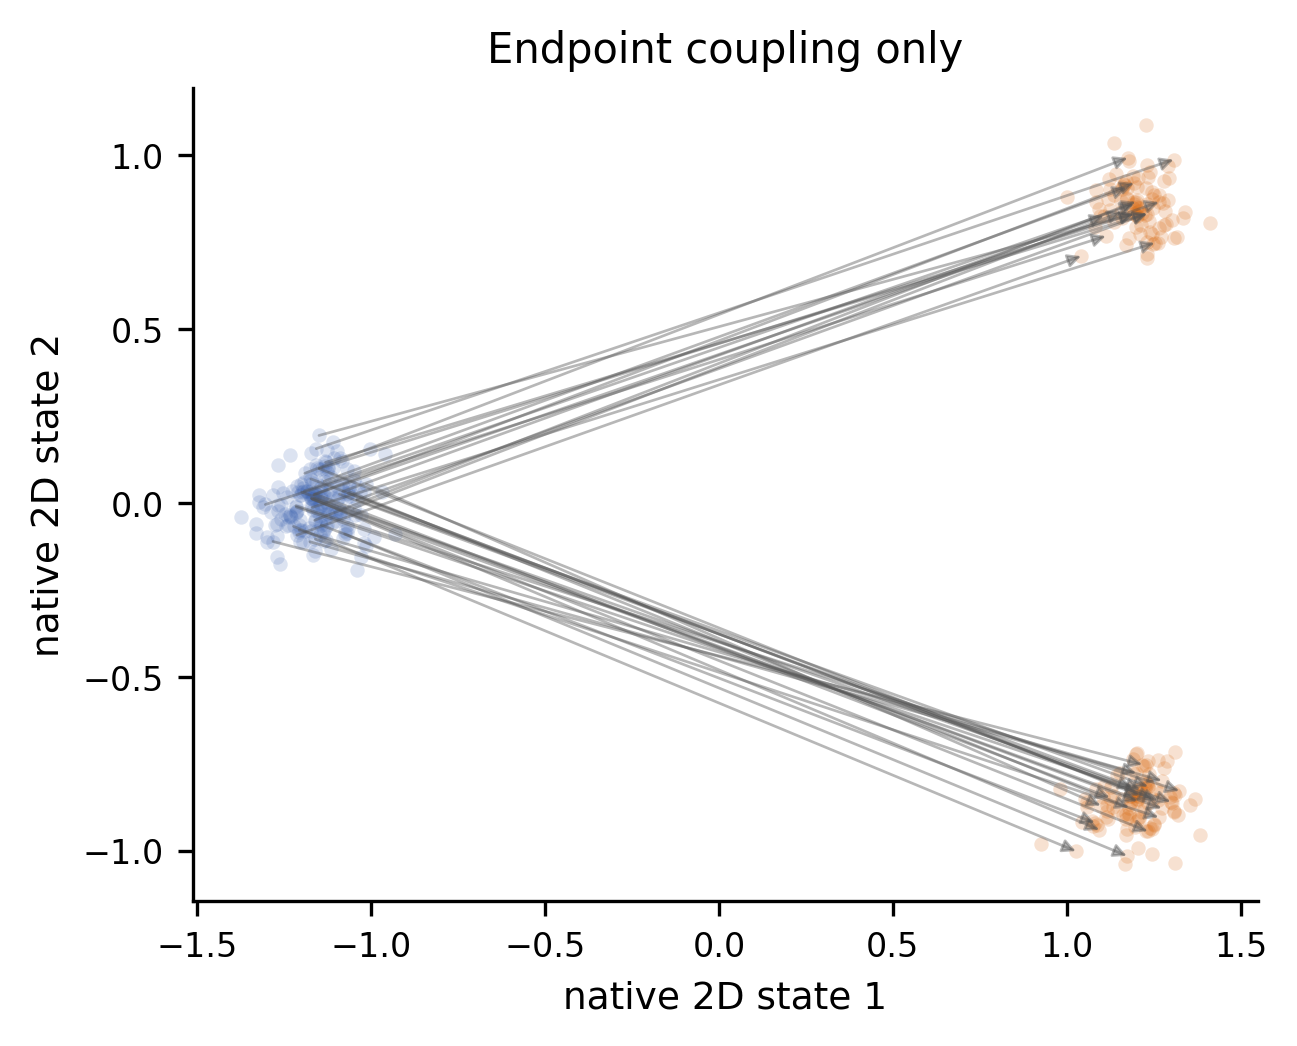

['figures/ch02/fig02_03a_endpoint_coupling_only.png',
 'figures/ch02/fig02_03a_endpoint_coupling_only.svg']

In [20]:
background_kw = dict(s=12, alpha=0.18, linewidths=0)
fig, ax = plt.subplots(figsize=(4.4, 3.8))
ax.scatter(toy_X0[:, 0], toy_X0[:, 1], c="#4267B2", **background_kw)
ax.scatter(toy_X1[:, 0], toy_X1[:, 1], c="#D55E00", **background_kw)
draw_arrows(ax, toy_X0, toy_X1, toy_i0[:38], toy_i1[:38], color="#555555", alpha=0.42, linewidth=0.65, mutation_scale=6.5)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("native 2D state 1")
ax.set_ylabel("native 2D state 2")
ax.set_title("Endpoint coupling only")
fig.tight_layout()
fig02_03a_paths = save_fig_both(fig, fig_dir, "fig02_03a_endpoint_coupling_only", paper_root)
show_saved_png(fig_dir, "fig02_03a_endpoint_coupling_only")
fig02_03a_paths


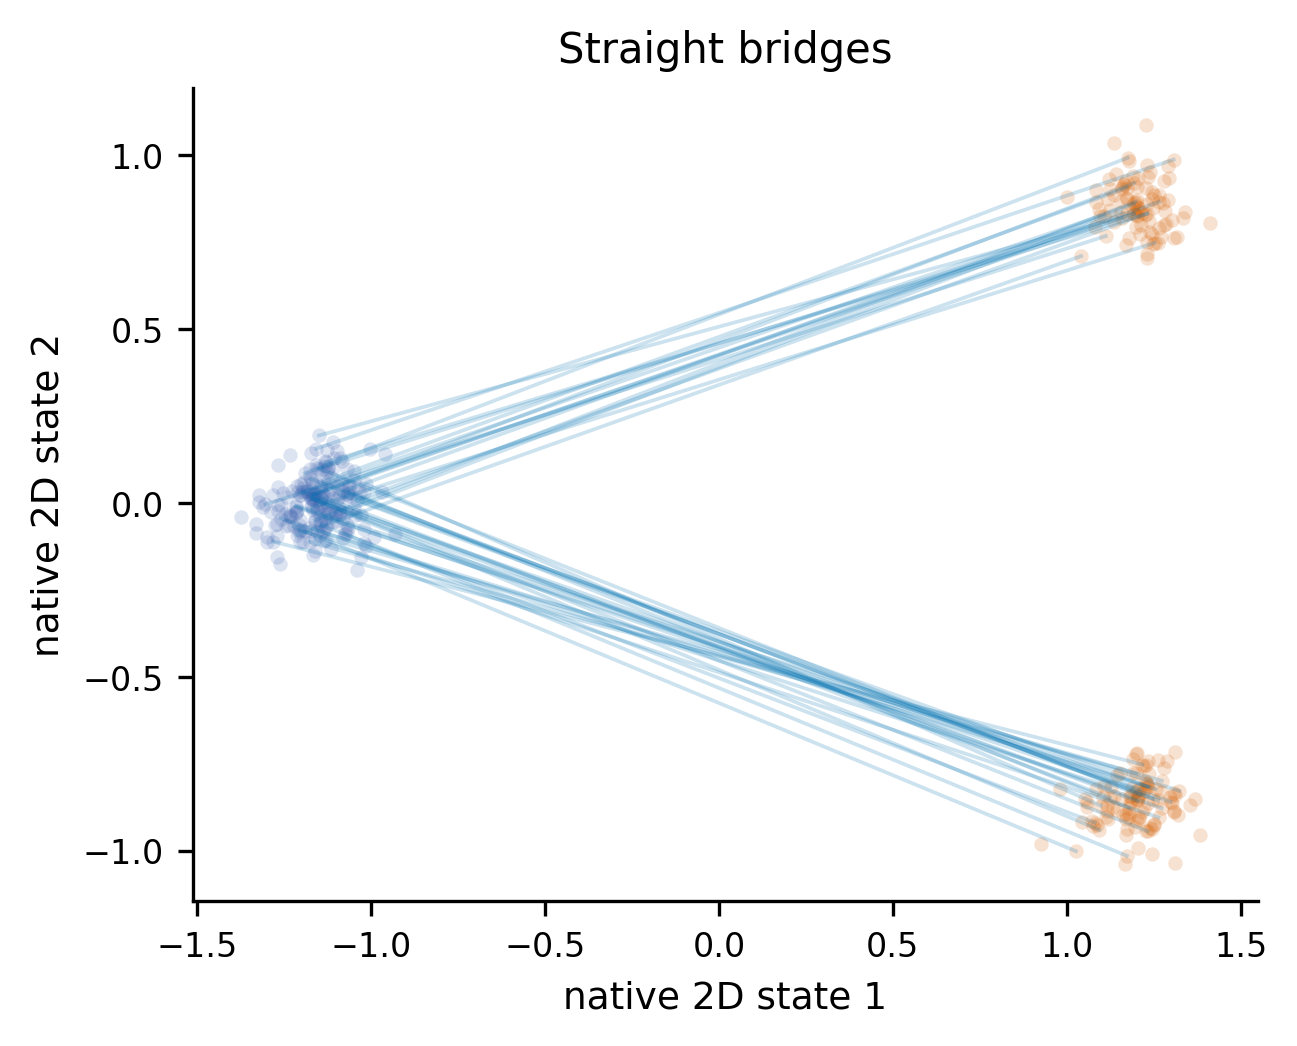

['figures/ch02/fig02_03b_straight_bridges.png',
 'figures/ch02/fig02_03b_straight_bridges.svg']

In [21]:
background_kw = dict(s=12, alpha=0.18, linewidths=0)
path_count = 42
fig, ax = plt.subplots(figsize=(4.4, 3.8))
ax.scatter(toy_X0[:, 0], toy_X0[:, 1], c="#4267B2", **background_kw)
ax.scatter(toy_X1[:, 0], toy_X1[:, 1], c="#D55E00", **background_kw)
for pair_idx in range(path_count):
    ax.plot(straight_bridge[:, pair_idx, 0], straight_bridge[:, pair_idx, 1], color="#0072B2", alpha=0.20, linewidth=0.9)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("native 2D state 1")
ax.set_ylabel("native 2D state 2")
ax.set_title("Straight bridges")
fig.tight_layout()
fig02_03b_paths = save_fig_both(fig, fig_dir, "fig02_03b_straight_bridges", paper_root)
show_saved_png(fig_dir, "fig02_03b_straight_bridges")
fig02_03b_paths


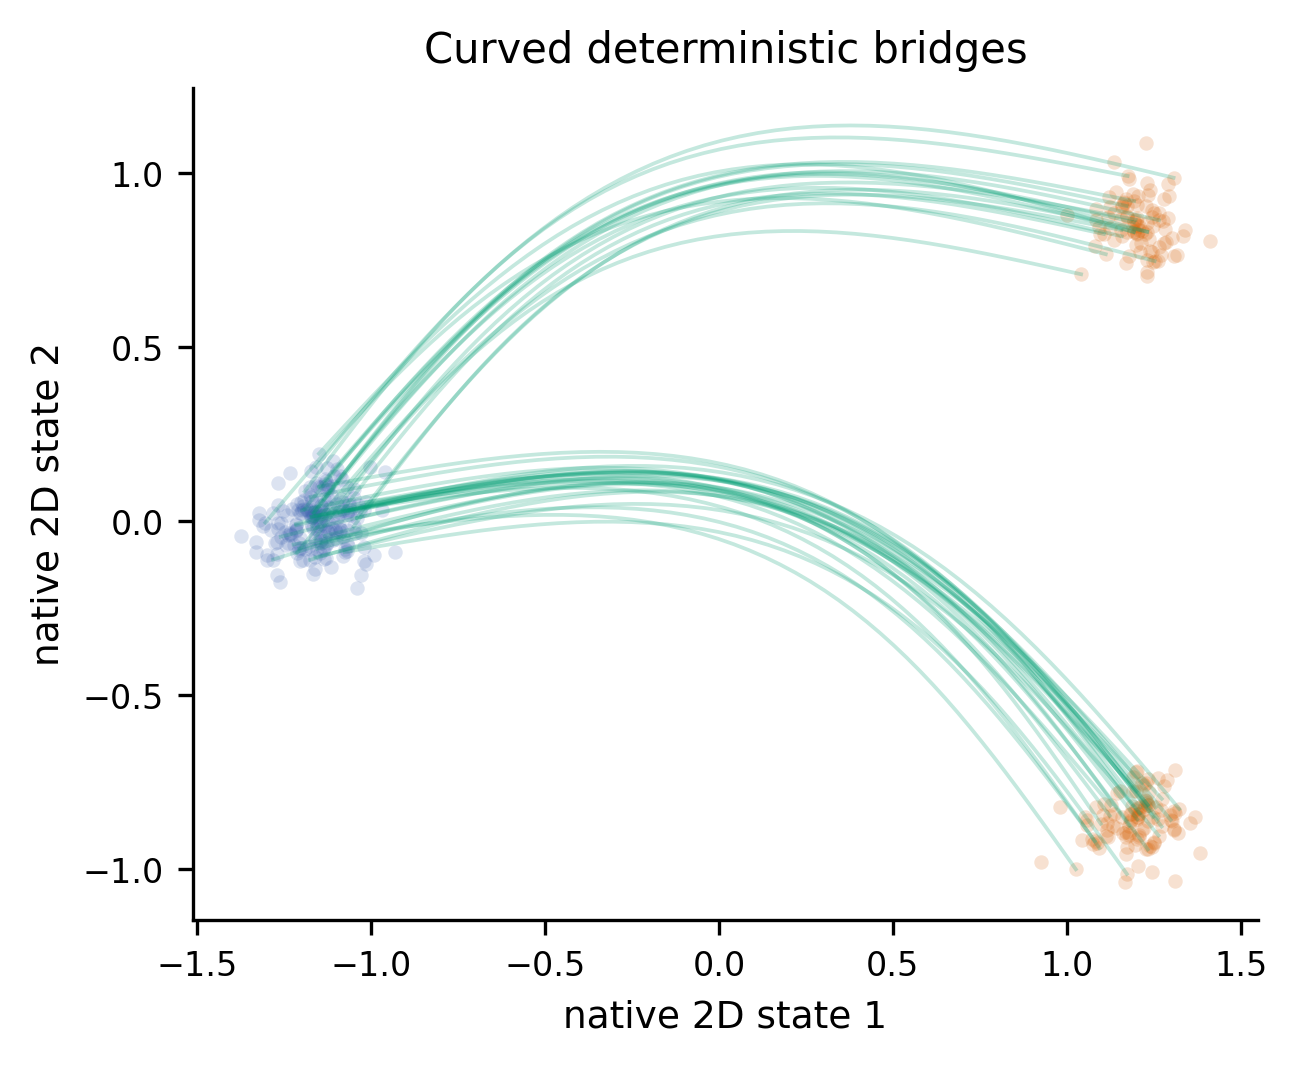

['figures/ch02/fig02_03c_curved_bridges.png',
 'figures/ch02/fig02_03c_curved_bridges.svg']

In [22]:
background_kw = dict(s=12, alpha=0.18, linewidths=0)
path_count = 42
fig, ax = plt.subplots(figsize=(4.4, 3.8))
ax.scatter(toy_X0[:, 0], toy_X0[:, 1], c="#4267B2", **background_kw)
ax.scatter(toy_X1[:, 0], toy_X1[:, 1], c="#D55E00", **background_kw)
for pair_idx in range(path_count):
    ax.plot(curved_bridge[:, pair_idx, 0], curved_bridge[:, pair_idx, 1], color="#009E73", alpha=0.23, linewidth=0.9)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("native 2D state 1")
ax.set_ylabel("native 2D state 2")
ax.set_title("Curved deterministic bridges")
fig.tight_layout()
fig02_03c_paths = save_fig_both(fig, fig_dir, "fig02_03c_curved_bridges", paper_root)
show_saved_png(fig_dir, "fig02_03c_curved_bridges")
fig02_03c_paths


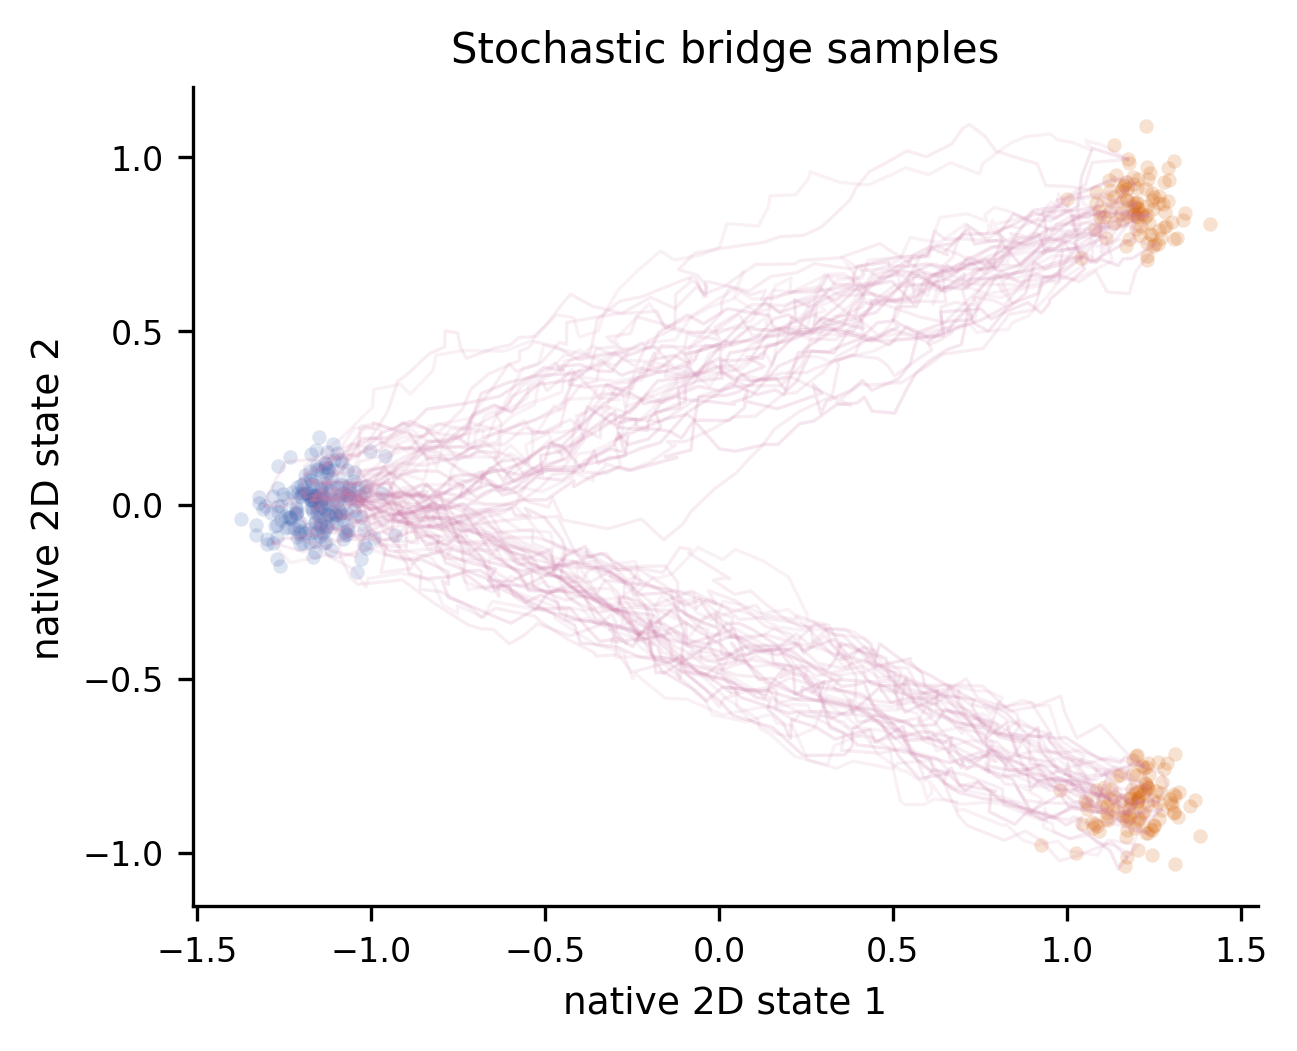

['figures/ch02/fig02_03d_stochastic_bridge_samples.png',
 'figures/ch02/fig02_03d_stochastic_bridge_samples.svg']

In [23]:
background_kw = dict(s=12, alpha=0.18, linewidths=0)
fig, ax = plt.subplots(figsize=(4.4, 3.8))
ax.scatter(toy_X0[:, 0], toy_X0[:, 1], c="#4267B2", **background_kw)
ax.scatter(toy_X1[:, 0], toy_X1[:, 1], c="#D55E00", **background_kw)
for repeat, alpha in enumerate([0.18, 0.13, 0.10]):
    stoch_plot = brownian_bridge_trajectories(toy_x0[:24], toy_x1[:24], tau_grid, sigma=0.23, seed=seed + 30 + repeat)
    for pair_idx in range(stoch_plot.shape[1]):
        ax.plot(stoch_plot[:, pair_idx, 0], stoch_plot[:, pair_idx, 1], color="#CC79A7", alpha=alpha, linewidth=0.8)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("native 2D state 1")
ax.set_ylabel("native 2D state 2")
ax.set_title("Stochastic bridge samples")
fig.tight_layout()
fig02_03d_paths = save_fig_both(fig, fig_dir, "fig02_03d_stochastic_bridge_samples", paper_root)
show_saved_png(fig_dir, "fig02_03d_stochastic_bridge_samples")
fig02_03d_paths


In [24]:
fig02_03_paths = fig02_03a_paths + fig02_03b_paths + fig02_03c_paths + fig02_03d_paths
fig02_03_paths


['figures/ch02/fig02_03a_endpoint_coupling_only.png',
 'figures/ch02/fig02_03a_endpoint_coupling_only.svg',
 'figures/ch02/fig02_03b_straight_bridges.png',
 'figures/ch02/fig02_03b_straight_bridges.svg',
 'figures/ch02/fig02_03c_curved_bridges.png',
 'figures/ch02/fig02_03c_curved_bridges.svg',
 'figures/ch02/fig02_03d_stochastic_bridge_samples.png',
 'figures/ch02/fig02_03d_stochastic_bridge_samples.svg']

**Claim Boundary.** These bridges share endpoint pairs but differ between endpoints. The example shows non-identifiability of paths from endpoint couplings; it is not a lineage reconstruction and it is not evidence that any one toy bridge is biologically observed.


## 6. Dynamic OT Low-Action Intuition On EB

Question: why does dynamic OT motivate low-action paths through the data geometry? We compare a fixed set of EB source-target endpoint pairs under two constructed path families: a straight PC-20 bridge and a perpendicular PC-20 detour.

The endpoints and PC-20 OT coupling are held fixed. Only the intermediate path is changed. PHATE is used only to display selected endpoints, while all action proxies are computed in PC-20. This is a diagnostic construction, not a solved Benamou-Brenier dynamic OT problem and not observed lineage.


In [25]:
try:
    import phate
except ImportError as exc:
    raise ImportError("phate is required for Chapter 2 EB endpoint visualization.") from exc

phate_model = phate.PHATE(
    n_components=2,
    knn=5,
    decay=40,
    n_landmark=min(2000, int(X_pc20.shape[0])),
    random_state=int(seed),
    n_jobs=1,
    verbose=0,
)
phate_model.fit(X_pc20)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Pre-fit PHATE should not be used.*")
    X_phate_fit = np.asarray(phate_model.transform(X_pc20), dtype=float)

X_phate_fit.shape


  SGD-MDS may not have converged: stress changed by -1.4% in final iterations. Consider increasing n_iter or adjusting learning_rate.


(4500, 2)

In [26]:
rng_dynamic = np.random.default_rng(seed + 40)
dynamic_colors = {
    "background": "#9ca3af",
    "connection": "#6b7280",
    "source": "#1f77b4",
    "target": "#d95f02",
    "straight": "#1f77b4",
    "detour": "#d95f02",
    "mean": "#111111",
}
dynamic_colors


{'background': '#9ca3af',
 'connection': '#6b7280',
 'source': '#1f77b4',
 'target': '#d95f02',
 'straight': '#1f77b4',
 'detour': '#d95f02',
 'mean': '#111111'}

In [27]:
pair_i0, pair_i1 = sample_pair_indices_from_coupling(pi_main, batch_size=20, seed=seed + 60)
dynamic_pair_x0 = X0_cost[pair_i0]
dynamic_pair_x1 = X1_cost[pair_i1]
dynamic_source_phate = X_phate_fit[idx0[pair_i0]]
dynamic_target_phate = X_phate_fit[idx1[pair_i1]]
dynamic_tau_grid = np.linspace(0.0, 1.0, 41)

economical_pc20 = (
    (1.0 - dynamic_tau_grid[:, None, None]) * dynamic_pair_x0[None, :, :]
    + dynamic_tau_grid[:, None, None] * dynamic_pair_x1[None, :, :]
)

direction = dynamic_pair_x1 - dynamic_pair_x0
random_vec = rng_dynamic.normal(size=direction.shape)
projection = (
    np.sum(random_vec * direction, axis=1, keepdims=True)
    / np.clip(np.sum(direction**2, axis=1, keepdims=True), 1e-12, None)
) * direction
perpendicular = random_vec - projection
perpendicular /= np.clip(np.linalg.norm(perpendicular, axis=1, keepdims=True), 1e-12, None)
amplitude = 0.75 * np.linalg.norm(direction, axis=1, keepdims=True)
detour_pc20 = economical_pc20 + np.sin(np.pi * dynamic_tau_grid)[:, None, None] * amplitude[None, :, :] * perpendicular[None, :, :]

sampled_dynamic_endpoint_pairs = pd.DataFrame(
    {
        "source_local_index": pair_i0,
        "target_local_index": pair_i1,
        "source_global_index": idx0[pair_i0],
        "target_global_index": idx1[pair_i1],
        "coupling": "same_pc20_sinkhorn_ot_coupling",
    }
)
sampled_dynamic_endpoint_pairs.head()


,source_local_index,target_local_index,source_global_index,target_global_index,coupling
0,39,244,1033,2682,same_pc20_sinkhorn_ot_coupling
1,146,142,1410,2356,same_pc20_sinkhorn_ot_coupling
2,205,237,1589,2642,same_pc20_sinkhorn_ot_coupling
3,74,92,1172,2169,same_pc20_sinkhorn_ot_coupling
4,171,10,1489,1847,same_pc20_sinkhorn_ot_coupling


In [28]:
straight_action_per_pair = action_per_pair_pc(economical_pc20, dynamic_tau_grid)
detour_action_per_pair = action_per_pair_pc(detour_pc20, dynamic_tau_grid)
energy_economical, length_economical = energy_and_length_pc(economical_pc20, dynamic_tau_grid)
energy_detour, length_detour = energy_and_length_pc(detour_pc20, dynamic_tau_grid)

if not np.isclose(energy_economical, straight_action_per_pair.mean()):
    raise ValueError("Straight action mean does not match aggregate PC-20 energy proxy.")
if not np.isclose(energy_detour, detour_action_per_pair.mean()):
    raise ValueError("Detour action mean does not match aggregate PC-20 energy proxy.")

dynamic_ot_energy_ratio_detour_over_economical = energy_detour / max(energy_economical, 1e-12)
pair_action_table = pd.DataFrame(
    {
        "pair_index": np.arange(len(straight_action_per_pair), dtype=int),
        "straight_action_pc20": straight_action_per_pair,
        "detour_action_pc20": detour_action_per_pair,
        "detour_over_straight": detour_action_per_pair / np.clip(straight_action_per_pair, 1e-12, None),
    }
)

energy_table = pd.DataFrame(
    [
        {
            "path_family": "straight_pc20",
            "energy_proxy": energy_economical,
            "mean_path_length_pc20": length_economical,
            "n_pairs": int(len(dynamic_pair_x0)),
            "n_steps": int(len(dynamic_tau_grid)),
            "notes": "Straight PC-20 bridge for the same sampled OT endpoint pairs.",
        },
        {
            "path_family": "detour_perpendicular_pc20",
            "energy_proxy": energy_detour,
            "mean_path_length_pc20": length_detour,
            "n_pairs": int(len(dynamic_pair_x0)),
            "n_steps": int(len(dynamic_tau_grid)),
            "notes": "Fixed perpendicular perturbation in PC-20; endpoints and coupling unchanged.",
        },
    ]
)
table02_03_path = save_ch02_table(energy_table, out_dir, "table02_03_dynamic_ot_energy_proxy.csv", paper_root)
table_preview(energy_table, columns=["path_family", "energy_proxy", "mean_path_length_pc20", "n_pairs", "n_steps"], n=8)


,path_family,energy_proxy,mean_path_length_pc20,n_pairs,n_steps
0,straight_pc20,204.625449,13.462652,20,41
1,detour_perpendicular_pc20,772.338220,25.121004,20,41


In [29]:
dynamic_chord_progress = dynamic_tau_grid.copy()
dynamic_detour_displacement = np.sin(np.pi * dynamic_chord_progress)[:, None] * amplitude.ravel()[None, :]
amplitude_order = np.argsort(amplitude.ravel())
representative_dynamic_pairs = amplitude_order[np.linspace(
    0,
    len(amplitude_order) - 1,
    min(5, len(amplitude_order)),
    dtype=int,
)]

{
    "n_fixed_endpoint_pairs": int(len(dynamic_pair_x0)),
    "n_representative_pairs_for_panel_b": int(len(representative_dynamic_pairs)),
    "mean_straight_action_pc20": float(straight_action_per_pair.mean()),
    "mean_detour_action_pc20": float(detour_action_per_pair.mean()),
    "mean_detour_over_straight": float(dynamic_ot_energy_ratio_detour_over_economical),
}


{'n_fixed_endpoint_pairs': 20,
 'n_representative_pairs_for_panel_b': 5,
 'mean_straight_action_pc20': 204.62544872616726,
 'mean_detour_action_pc20': 772.3382200447031,
 'mean_detour_over_straight': 3.774399640184822}

**Panel Output.** Dynamic OT low-action intuition is saved as three separate panel-level figures: fixed EB endpoint pairs, path-local construction with fixed endpoints, and a paired PC-20 action proxy. PHATE appears only in the endpoint display panel.


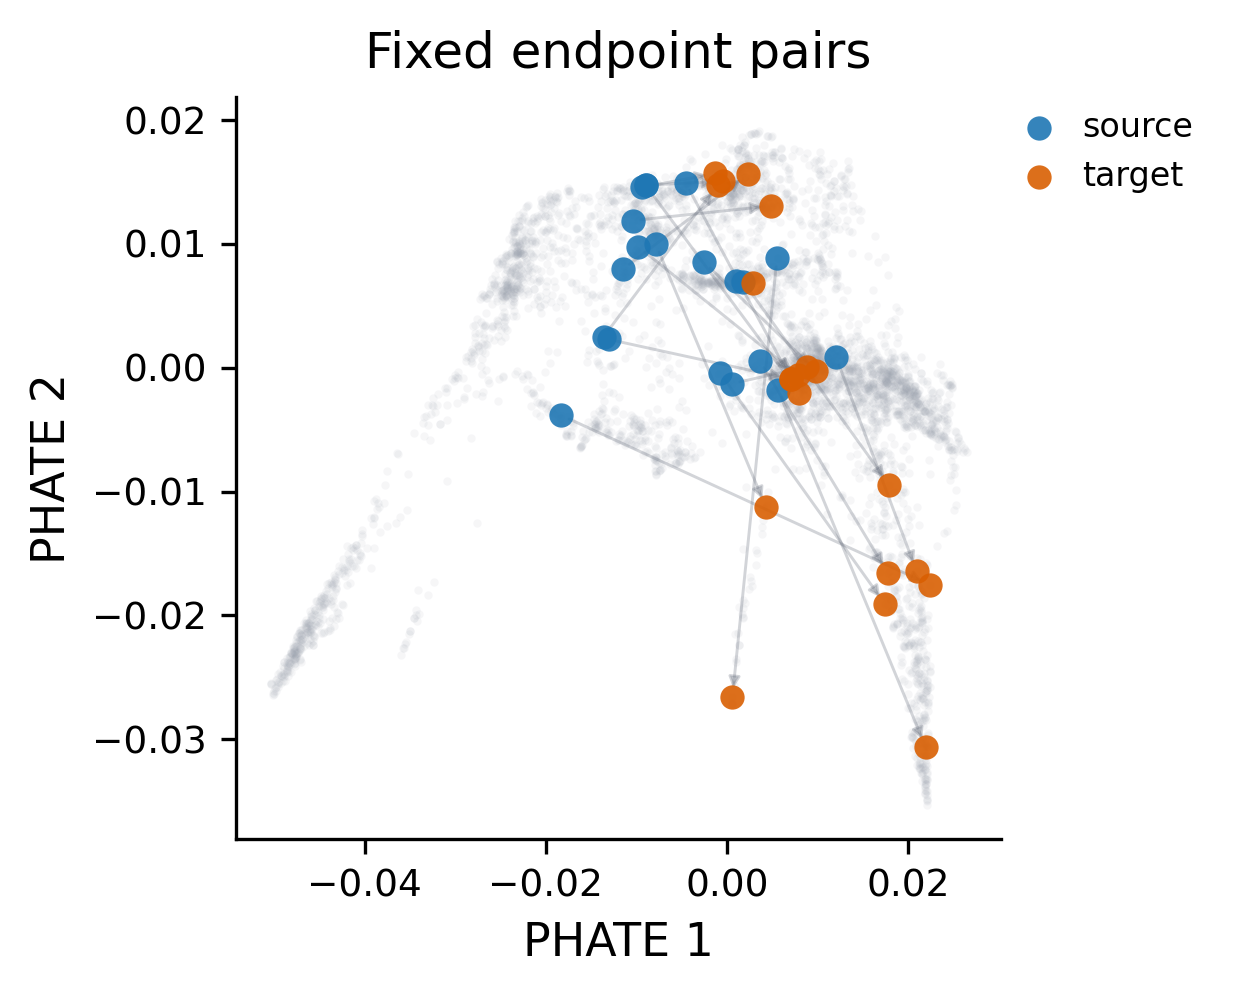

['figures/ch02/fig02_04a_fixed_endpoint_pairs.png',
 'figures/ch02/fig02_04a_fixed_endpoint_pairs.svg']

In [30]:
fig, ax = plt.subplots(figsize=(4.2, 3.4))
draw_fixed_endpoint_pairs_panel(
    ax,
    X_phate_fit,
    dynamic_source_phate,
    dynamic_target_phate,
    dynamic_colors,
)
fig.tight_layout()
fig02_04a_paths = save_fig_both(fig, fig_dir, "fig02_04a_fixed_endpoint_pairs", paper_root)
show_saved_png(fig_dir, "fig02_04a_fixed_endpoint_pairs")
fig02_04a_paths


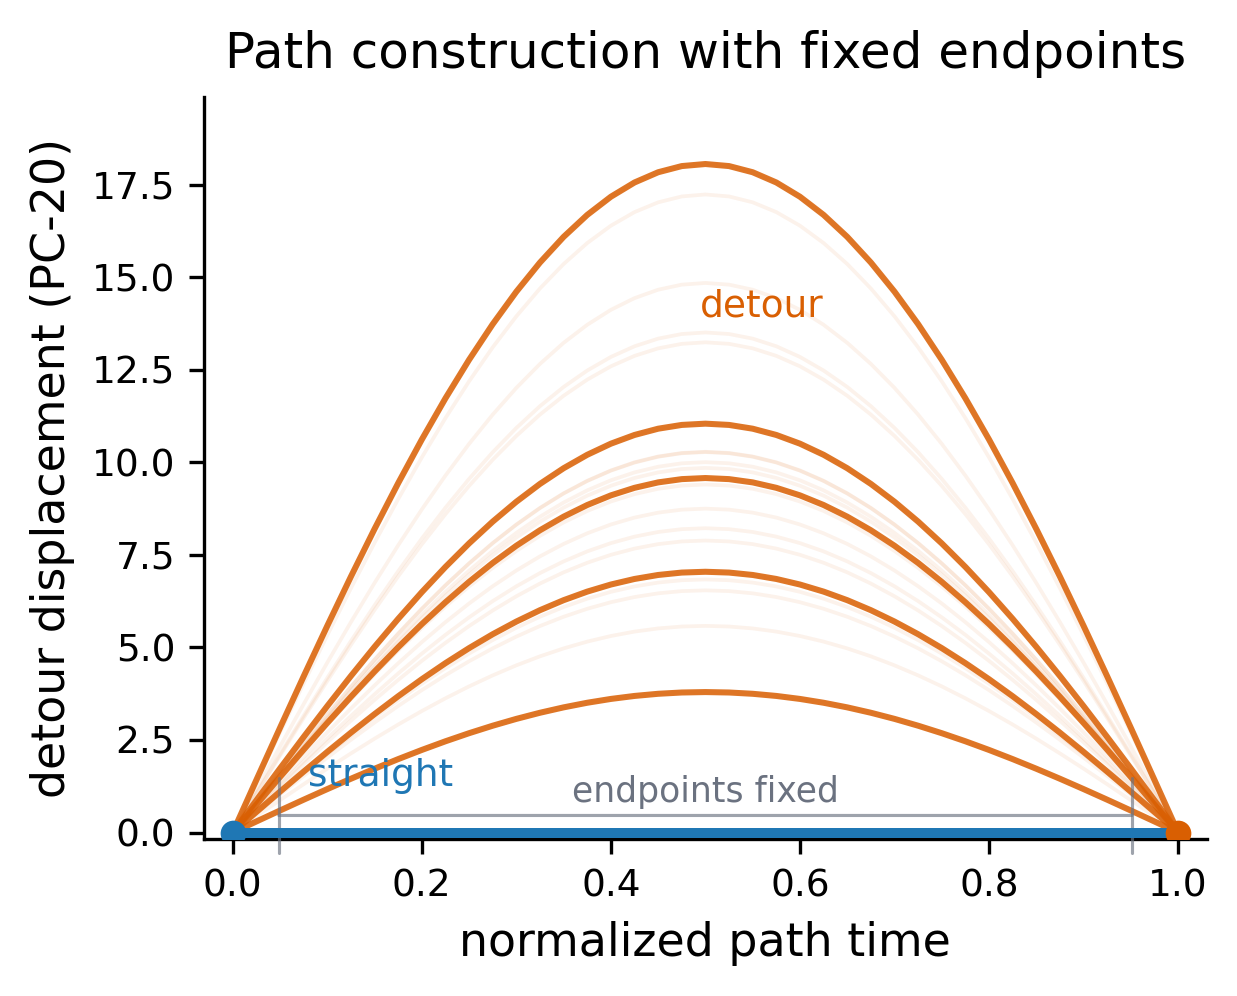

['figures/ch02/fig02_04b_path_construction_fixed_endpoints.png',
 'figures/ch02/fig02_04b_path_construction_fixed_endpoints.svg']

In [31]:
title_fontsize = 12
label_fontsize = 11
tick_fontsize = 9

fig, ax = plt.subplots(figsize=(4.2, 3.4))
ax.set_facecolor("white")
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=tick_fontsize)
max_amp = max(float(dynamic_detour_displacement.max()), 1e-12)
for pair_idx in range(dynamic_detour_displacement.shape[1]):
    ax.plot(
        dynamic_chord_progress,
        dynamic_detour_displacement[:, pair_idx],
        color=dynamic_colors["detour"],
        alpha=0.08,
        linewidth=0.9,
        zorder=1,
    )
for pair_idx in representative_dynamic_pairs:
    ax.plot(
        dynamic_chord_progress,
        dynamic_detour_displacement[:, pair_idx],
        color=dynamic_colors["detour"],
        alpha=0.85,
        linewidth=1.45,
        zorder=3,
    )
ax.plot(dynamic_chord_progress, np.zeros_like(dynamic_chord_progress), color=dynamic_colors["straight"], linewidth=2.4, zorder=4)
ax.scatter([0], [0], s=38, c=dynamic_colors["source"], linewidths=0, zorder=5)
ax.scatter([1], [0], s=38, c=dynamic_colors["target"], linewidths=0, zorder=5)
ax.text(0.08, 1.05, "straight", color=dynamic_colors["straight"], fontsize=9, ha="left", va="bottom")
ax.text(0.56, max_amp * 0.76, "detour", color=dynamic_colors["detour"], fontsize=9, ha="center", va="bottom")
fixed_y = 0.46
ax.annotate(
    "",
    xy=(0.96, fixed_y),
    xytext=(0.04, fixed_y),
    arrowprops={"arrowstyle": "|-|", "color": dynamic_colors["connection"], "lw": 0.75, "alpha": 0.65},
)
ax.text(0.5, fixed_y + 0.18, "endpoints fixed", color=dynamic_colors["connection"], fontsize=8.3, ha="center", va="bottom")
ax.set_xlim(-0.03, 1.03)
ax.set_ylim(-0.18, max_amp * 1.10)
ax.set_title("Path construction with fixed endpoints", fontsize=title_fontsize, pad=7)
ax.set_xlabel("normalized path time", fontsize=label_fontsize)
ax.set_ylabel("detour displacement (PC-20)", fontsize=label_fontsize)
fig.tight_layout()
fig02_04b_paths = save_fig_both(fig, fig_dir, "fig02_04b_path_construction_fixed_endpoints", paper_root)
show_saved_png(fig_dir, "fig02_04b_path_construction_fixed_endpoints")
fig02_04b_paths


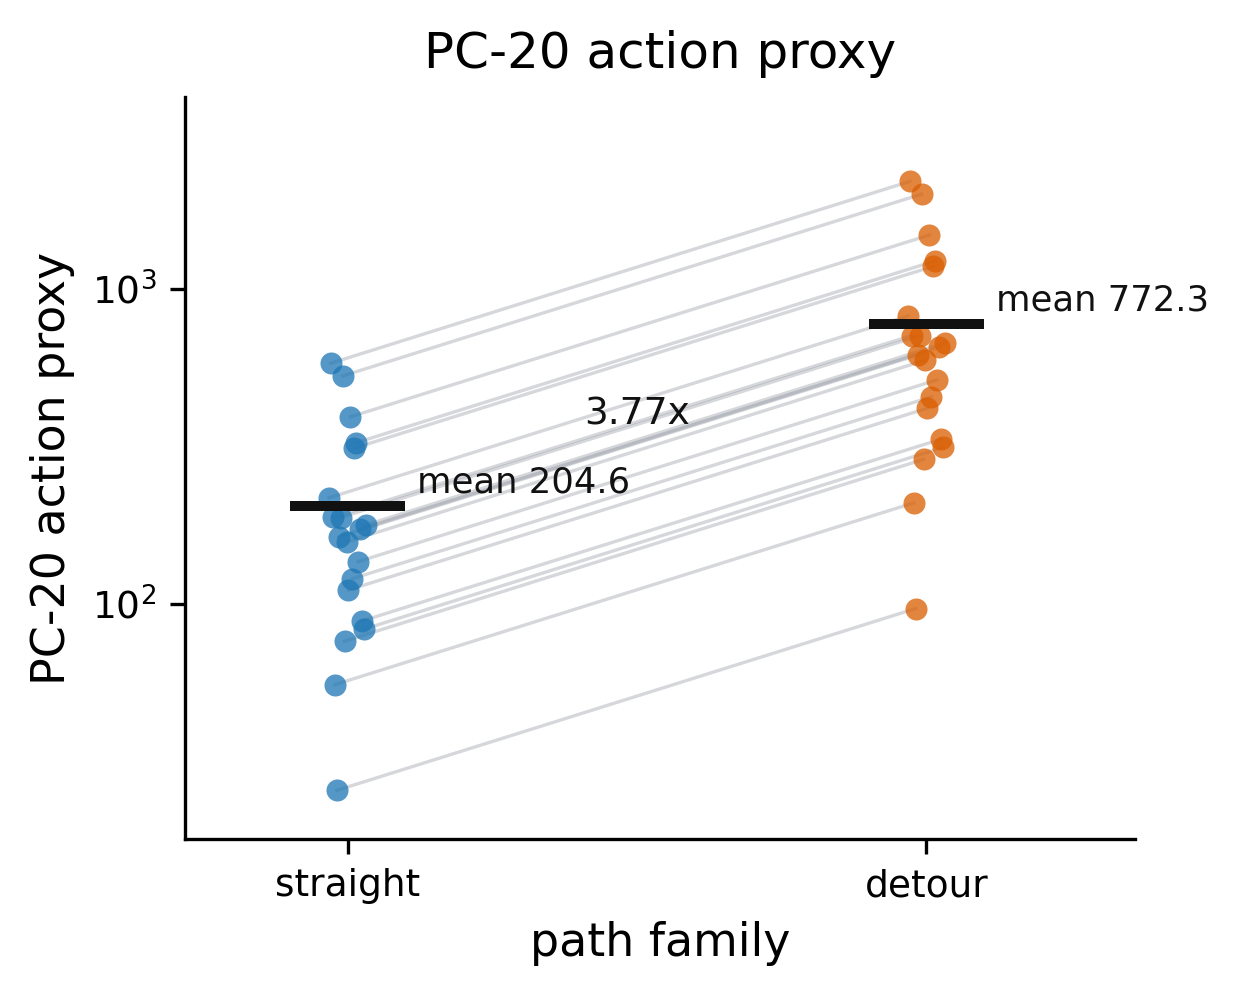

['figures/ch02/fig02_04c_pc20_action_proxy.png',
 'figures/ch02/fig02_04c_pc20_action_proxy.svg']

In [32]:
title_fontsize = 12
label_fontsize = 11
tick_fontsize = 9

fig, ax = plt.subplots(figsize=(4.2, 3.4))
ax.set_facecolor("white")
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=tick_fontsize)
pair_jitter = np.linspace(-0.032, 0.032, len(pair_action_table))
x_straight = np.zeros(len(pair_action_table)) + pair_jitter
x_detour = np.ones(len(pair_action_table)) + pair_jitter
min_action = float(min(straight_action_per_pair.min(), detour_action_per_pair.min()))
max_action = float(max(straight_action_per_pair.max(), detour_action_per_pair.max()))
for x0_line, x1_line, y0, y1 in zip(x_straight, x_detour, straight_action_per_pair, detour_action_per_pair):
    ax.plot([x0_line, x1_line], [y0, y1], color=dynamic_colors["connection"], alpha=0.28, linewidth=0.8, zorder=1)
ax.scatter(x_straight, straight_action_per_pair, s=28, c=dynamic_colors["straight"], alpha=0.76, linewidths=0, zorder=3)
ax.scatter(x_detour, detour_action_per_pair, s=28, c=dynamic_colors["detour"], alpha=0.76, linewidths=0, zorder=3)

mean_straight_action = float(straight_action_per_pair.mean())
mean_detour_action = float(detour_action_per_pair.mean())
ax.hlines(mean_straight_action, -0.10, 0.10, color=dynamic_colors["mean"], linewidth=2.4, zorder=5)
ax.hlines(mean_detour_action, 0.90, 1.10, color=dynamic_colors["mean"], linewidth=2.4, zorder=5)
ax.set_yscale("log")
ax.set_ylim(max(min_action * 0.70, 1e-6), max_action * 1.85)
ax.set_xlim(-0.28, 1.36)
ax.set_xticks([0, 1], ["straight", "detour"])
ax.set_yticks([100, 1000])
ax.yaxis.set_major_formatter(mpl.ticker.LogFormatterMathtext(base=10))
ax.yaxis.set_minor_locator(mpl.ticker.NullLocator())
ax.set_title("PC-20 action proxy", fontsize=title_fontsize, pad=7)
ax.set_xlabel("path family", fontsize=label_fontsize)
ax.set_ylabel("PC-20 action proxy", fontsize=label_fontsize)
ax.text(0.12, mean_straight_action * 1.05, f"mean {mean_straight_action:.1f}", fontsize=8.5, ha="left", va="bottom", color=dynamic_colors["mean"])
ax.text(1.12, mean_detour_action * 1.05, f"mean {mean_detour_action:.1f}", fontsize=8.5, ha="left", va="bottom", color=dynamic_colors["mean"])
ax.text(
    0.50,
    np.sqrt(mean_straight_action * mean_detour_action),
    f"{dynamic_ot_energy_ratio_detour_over_economical:.2f}x",
    fontsize=9,
    ha="center",
    va="center",
    color=dynamic_colors["mean"],
)
fig.tight_layout()
fig02_04c_paths = save_fig_both(fig, fig_dir, "fig02_04c_pc20_action_proxy", paper_root)
show_saved_png(fig_dir, "fig02_04c_pc20_action_proxy")
fig02_04c_paths


In [33]:
fig02_04_paths = fig02_04a_paths + fig02_04b_paths + fig02_04c_paths
fig02_04_paths


['figures/ch02/fig02_04a_fixed_endpoint_pairs.png',
 'figures/ch02/fig02_04a_fixed_endpoint_pairs.svg',
 'figures/ch02/fig02_04b_path_construction_fixed_endpoints.png',
 'figures/ch02/fig02_04b_path_construction_fixed_endpoints.svg',
 'figures/ch02/fig02_04c_pc20_action_proxy.png',
 'figures/ch02/fig02_04c_pc20_action_proxy.svg']

**Caption.** Fixed EB endpoint pairs are compared under two constructed path families. Endpoints are held fixed; only the intermediate path is changed. Action is computed in PC-20, while PHATE is used only to display selected endpoint pairs. Detour paths increase the kinetic-action proxy relative to straight paths, illustrating the low-action prior behind dynamic OT. Arithmetic means are shown in the action panel. This is a diagnostic construction, not a solved dynamic OT problem or observed lineage.


## 7. CNF Solver-In-Loop Training Bottleneck Proxy

Question: what is the training-control-flow bottleneck when a learned velocity field is evaluated by rolling an ODE inside each optimization step?

This is a pedagogical Neural ODE solver-in-the-loop proxy. It is not full likelihood CNF and does not compare against Flow Matching. In quick mode it uses `n_steps = 100`, `batch_size = 256`, and `n_solver_steps = 16`.


In [34]:
import torch

torch.set_num_threads(min(max(torch.get_num_threads(), 1), 4))
device = "cpu"
batch_size = 256
n_steps = 100 if quick_mode else 200
n_solver_steps = 16 if quick_mode else 24
eval_solver_steps = 32

{"n_steps": n_steps, "batch_size": batch_size, "n_solver_steps": n_solver_steps}


{'n_steps': 100, 'batch_size': 256, 'n_solver_steps': 16}

In [35]:
set_seed(seed)
angles = torch.linspace(0, 2 * np.pi, 9, dtype=torch.float32)[:-1]
source_centers = torch.stack([1.2 * torch.cos(angles), 1.2 * torch.sin(angles)], dim=1).to(device)
rot = torch.tensor([[0.78, -0.62], [0.62, 0.78]], dtype=torch.float32, device=device)
target_centers = (source_centers @ rot.T) * torch.tensor([0.9, 1.15], device=device) + torch.tensor([0.65, -0.25], device=device)
torch_generator = torch.Generator(device=device)
torch_generator.manual_seed(seed)

def sample_source(n: int):
    return sample_gaussian_mixture_torch(n, source_centers, 0.16, torch_generator, device)


def sample_target(n: int):
    return sample_gaussian_mixture_torch(n, target_centers, 0.18, torch_generator, device)


cnf_proxy_model = VelocityMLP(x_dim=2, hidden_dim=64, hidden_layers=2).to(device)
cnf_proxy_optimizer = torch.optim.Adam(cnf_proxy_model.parameters(), lr=1e-3)


In [36]:
cnf_step_times = []
cnf_nfe_values = []
cnf_loss_trace = []
cnf_training_start = time.perf_counter()
final_loss = np.nan

for step in range(n_steps):
    x0_batch = sample_source(batch_size)
    target_batch = sample_target(batch_size)
    cnf_proxy_optimizer.zero_grad(set_to_none=True)
    step_start = time.perf_counter()
    pred_batch, nfe = euler_integrate_torch(cnf_proxy_model, x0_batch, n_solver_steps=n_solver_steps)
    loss = torch_mmd_rbf(pred_batch, target_batch, gamma=0.6)
    loss.backward()
    cnf_proxy_optimizer.step()
    elapsed = time.perf_counter() - step_start
    cnf_step_times.append(elapsed)
    cnf_nfe_values.append(nfe)
    final_loss = float(loss.detach().cpu())
    cnf_loss_trace.append(final_loss)

cnf_total_wall_time = time.perf_counter() - cnf_training_start
cnf_step_times = np.asarray(cnf_step_times)
cnf_nfe_values = np.asarray(cnf_nfe_values)
{"total_wall_time_sec": cnf_total_wall_time, "final_loss": final_loss}


{'total_wall_time_sec': 1.6512390710413456, 'final_loss': 0.011843204498291016}

In [37]:
with torch.no_grad():
    eval_source = sample_source(512)
    eval_target = sample_target(512)
    eval_pred, _ = euler_integrate_torch(cnf_proxy_model, eval_source.clone(), n_solver_steps=eval_solver_steps)

final_distribution_mmd = mmd_rbf(eval_pred.cpu().numpy(), eval_target.cpu().numpy())
cnf_training_table = pd.DataFrame(
    [
        {
            "method": "solver-in-the-loop Neural ODE training proxy",
            "n_steps": int(n_steps),
            "batch_size": int(batch_size),
            "mean_time_per_step_ms": float(cnf_step_times.mean() * 1000.0),
            "median_time_per_step_ms": float(np.median(cnf_step_times) * 1000.0),
            "nfe_per_step_mean": float(cnf_nfe_values.mean()),
            "nfe_per_step_median": float(np.median(cnf_nfe_values)),
            "total_wall_time_sec": float(cnf_total_wall_time),
            "final_loss": float(final_loss),
            "final_distribution_mmd": float(final_distribution_mmd),
            "notes": "Pedagogical proxy: backpropagates through a differentiable Euler ODE rollout with MMD loss; no likelihood or divergence tracking.",
        }
    ]
)
table02_04_path = save_ch02_table(cnf_training_table, out_dir, "table02_04_cnf_training_bottleneck.csv", paper_root)
table02_04_proxy_path = save_ch02_table(cnf_training_table, out_dir, "table02_04_training_cost_proxy.csv", paper_root)
table_preview(cnf_training_table, columns=["method", "n_steps", "mean_time_per_step_ms", "nfe_per_step_mean", "total_wall_time_sec", "final_distribution_mmd"], n=8)


,method,n_steps,mean_time_per_step_ms,nfe_per_step_mean,total_wall_time_sec,final_distribution_mmd
0,solver-in-the-loop Neural ODE training proxy,100,16.347255,16.0,1.651239,0.000787


In [38]:
label = ["solver-in-loop\nproxy"]
mean_step_ms = float(cnf_training_table.iloc[0]["mean_time_per_step_ms"])
median_step_ms = float(cnf_training_table.iloc[0]["median_time_per_step_ms"])
total_wall_sec = float(cnf_training_table.iloc[0]["total_wall_time_sec"])
nfe_per_step = float(cnf_training_table.iloc[0]["nfe_per_step_mean"])
final_mmd_value = float(cnf_training_table.iloc[0]["final_distribution_mmd"])

cnf_training_bottleneck_scalars = {
    "mean_time_per_step_ms": mean_step_ms,
    "median_time_per_step_ms": median_step_ms,
    "total_wall_time_sec": total_wall_sec,
    "nfe_per_step_mean": nfe_per_step,
    "final_distribution_mmd": final_mmd_value,
}
cnf_training_bottleneck_scalars


{'mean_time_per_step_ms': 16.347254663705826,
 'median_time_per_step_ms': 16.18899032473564,
 'total_wall_time_sec': 1.6512390710413456,
 'nfe_per_step_mean': 16.0,
 'final_distribution_mmd': 0.0007868466578970779}

**Panel Output.** The CNF proxy timing diagnostics are shown as scalar timing readouts so the solver-in-loop cost is visible without a hand-drawn control-flow schematic.


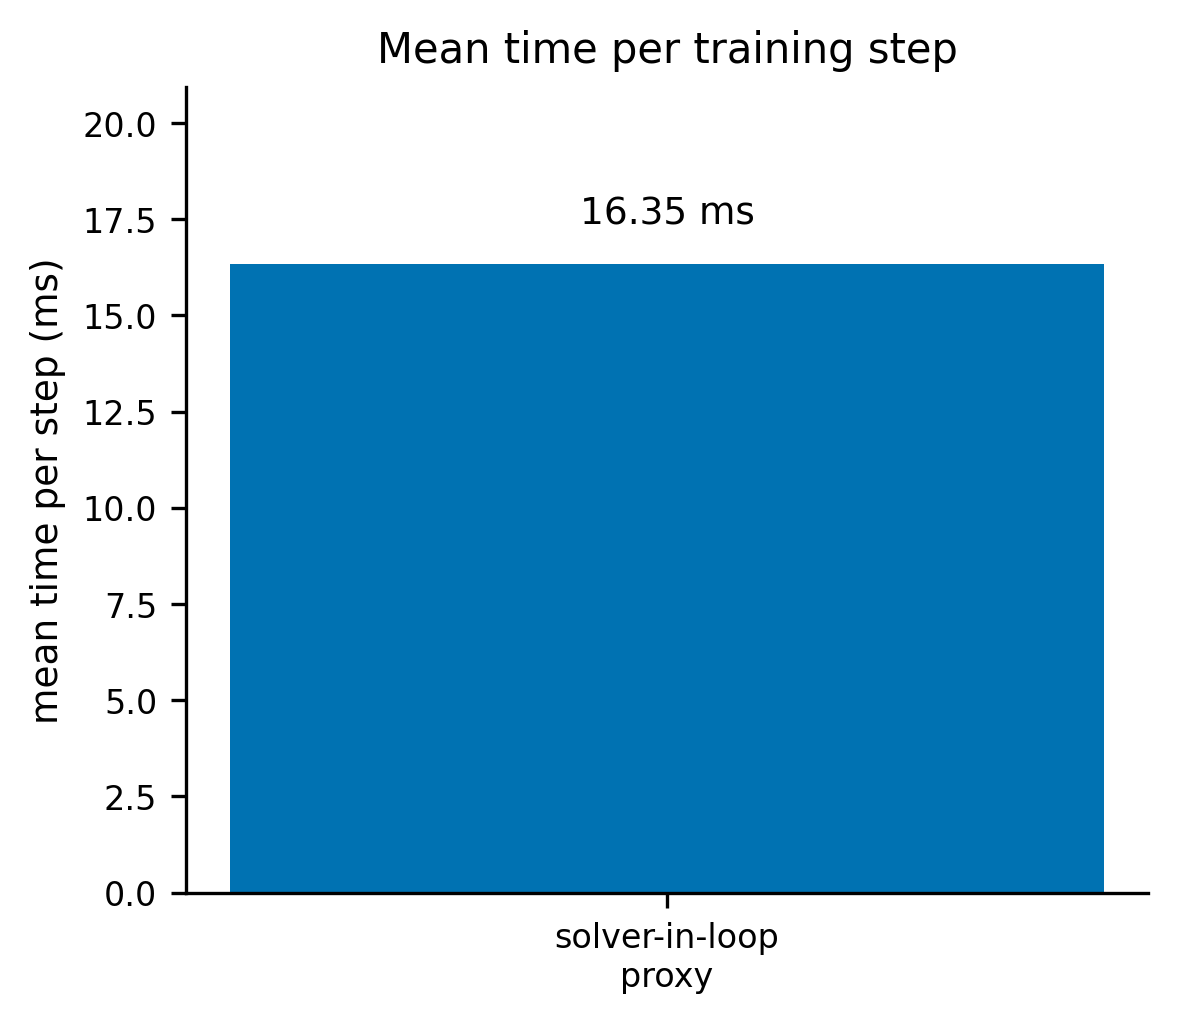

['figures/ch02/fig02_06b_mean_step_time.png',
 'figures/ch02/fig02_06b_mean_step_time.svg']

In [39]:
fig, ax = plt.subplots(figsize=(4.0, 3.5))
ax.bar(label, [mean_step_ms], color=["#0072B2"])
ax.set_ylabel("mean time per step (ms)")
ax.set_title("Mean time per training step")
ax.set_ylim(0.0, mean_step_ms * 1.28)
ax.text(0, mean_step_ms * 1.05, f"{mean_step_ms:.2f} ms", ha="center", va="bottom", fontsize=9)
fig.tight_layout()
fig02_06b_paths = save_fig_both(fig, fig_dir, "fig02_06b_mean_step_time", paper_root)
show_saved_png(fig_dir, "fig02_06b_mean_step_time")
fig02_06b_paths


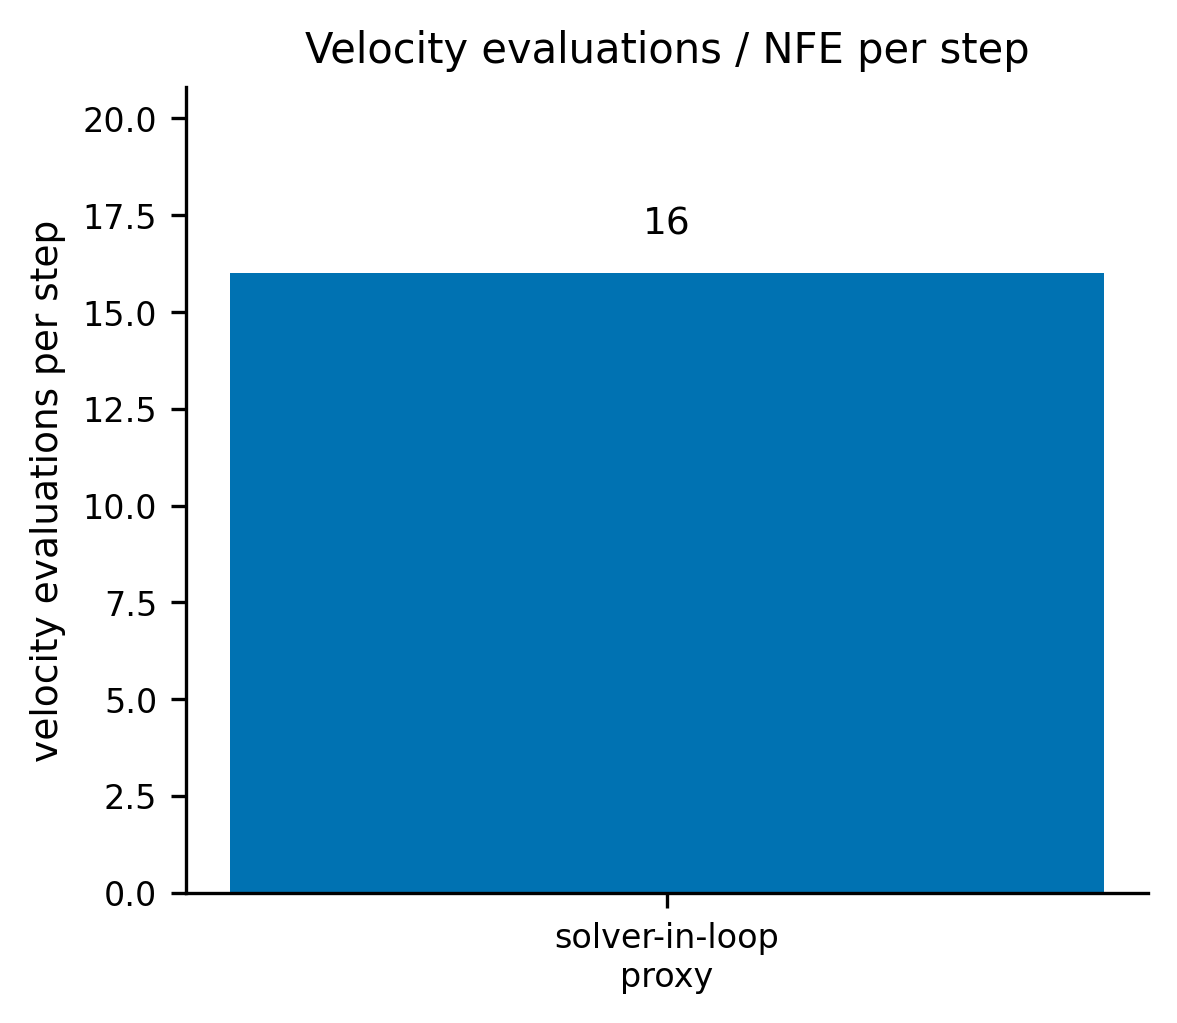

['figures/ch02/fig02_06c_velocity_evaluations_per_step.png',
 'figures/ch02/fig02_06c_velocity_evaluations_per_step.svg']

In [40]:
fig, ax = plt.subplots(figsize=(4.0, 3.5))
ax.bar(label, [nfe_per_step], color=["#0072B2"])
ax.set_ylabel("velocity evaluations per step")
ax.set_title("Velocity evaluations / NFE per step")
ax.set_ylim(0.0, nfe_per_step * 1.30)
ax.text(0, nfe_per_step * 1.05, f"{nfe_per_step:.0f}", ha="center", va="bottom", fontsize=9)
fig.tight_layout()
fig02_06c_paths = save_fig_both(fig, fig_dir, "fig02_06c_velocity_evaluations_per_step", paper_root)
show_saved_png(fig_dir, "fig02_06c_velocity_evaluations_per_step")
fig02_06c_paths


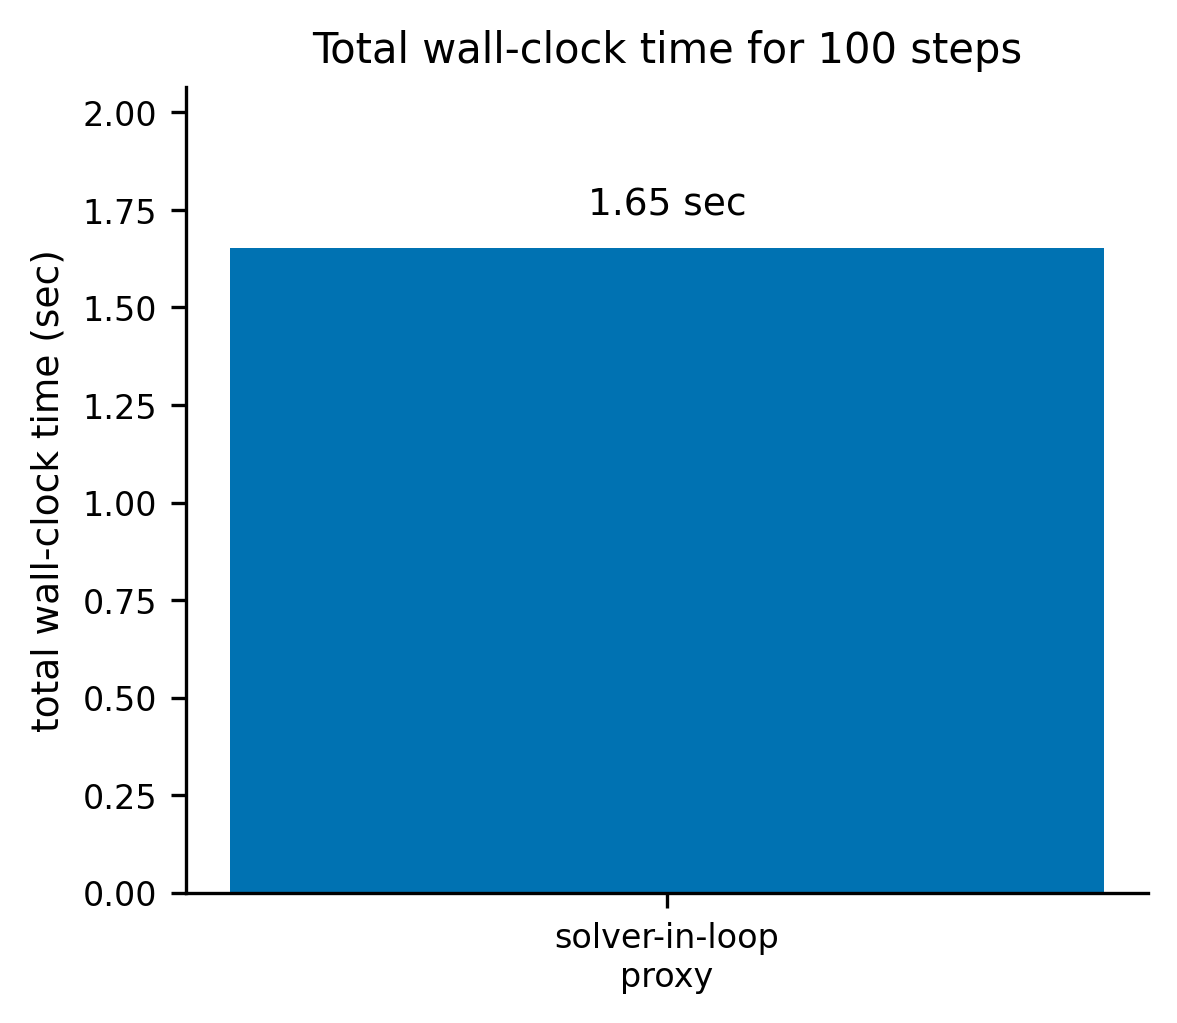

['figures/ch02/fig02_06d_total_wall_clock_time.png',
 'figures/ch02/fig02_06d_total_wall_clock_time.svg']

In [41]:
fig, ax = plt.subplots(figsize=(4.0, 3.5))
bars = ax.bar(label, [total_wall_sec], color=["#0072B2"])
ax.set_ylabel("total wall-clock time (sec)")
ax.set_title(f"Total wall-clock time for {n_steps} steps")
ax.set_ylim(0.0, total_wall_sec * 1.25)
for bar, value in zip(bars, [total_wall_sec]):
    ax.text(bar.get_x() + bar.get_width() / 2, float(value) + total_wall_sec * 0.04, f"{float(value):.2f} sec", ha="center", va="bottom", fontsize=9)
fig.tight_layout()
fig02_06d_paths = save_fig_both(fig, fig_dir, "fig02_06d_total_wall_clock_time", paper_root)
show_saved_png(fig_dir, "fig02_06d_total_wall_clock_time")
fig02_06d_paths


In [42]:
fig02_06_paths = fig02_06b_paths + fig02_06c_paths + fig02_06d_paths
fig02_06_paths


['figures/ch02/fig02_06b_mean_step_time.png',
 'figures/ch02/fig02_06b_mean_step_time.svg',
 'figures/ch02/fig02_06c_velocity_evaluations_per_step.png',
 'figures/ch02/fig02_06c_velocity_evaluations_per_step.svg',
 'figures/ch02/fig02_06d_total_wall_clock_time.png',
 'figures/ch02/fig02_06d_total_wall_clock_time.svg']

**Claim Boundary.** Solver-in-loop baseline is not full likelihood CNF. The table reports a pedagogical differentiable Euler rollout with an MMD endpoint loss. Chapter 2 stops at the CNF training bottleneck; Flow Matching training is deferred to Chapter 3.


## 8. Run Summary And Artifact Check

The final cell records the reproducibility settings, key scalar outputs, written artifacts, and concept boundaries in `outputs/ch02/ch02_run_summary.json`.


In [43]:
figures_written = fig02_02_paths + fig02_03_paths + fig02_04_paths + fig02_06_paths
provenance_tables_written = [table02_04_proxy_path]
tables_written = [
    table02_01_path,
    table02_optional_path,
    table02_02_path,
    table02_03_path,
    table02_04_path,
    table02_04_proxy_path,
]

summary = {
    "quick_mode": bool(quick_mode),
    "seed": int(seed),
    "runtime_sec": float(time.perf_counter() - started),
    "eb_path": str(eb_path.relative_to(PROJECT_ROOT)),
    "source_time": source_time,
    "target_time": target_time,
    "n_source_ot": int(len(X0_cost)),
    "n_target_ot": int(len(X1_cost)),
    "cost_space": cost_space,
    "visualization_space": visualization_space,
    "phate_transform_used": True,
    "phate_installed": True,
    "static_ot_cost_scale": "median_positive_cost",
    "static_ot_cost_scale_value": float(cost_scale),
    "static_ot_main_epsilon": float(static_ot_main_epsilon),
    "sinkhorn_backend_main_epsilon": str(sinkhorn_infos[static_ot_main_epsilon].get("backend", "")),
    "dynamic_ot_energy_ratio_detour_over_economical": float(dynamic_ot_energy_ratio_detour_over_economical),
    "dynamic_ot_straight_action_mean_pc20": float(straight_action_per_pair.mean()),
    "dynamic_ot_detour_action_mean_pc20": float(detour_action_per_pair.mean()),
    "dynamic_ot_n_endpoint_pairs": int(len(pair_action_table)),
    "cnf_proxy_mean_step_time_ms": float(mean_step_ms),
    "cnf_proxy_nfe_per_step": float(nfe_per_step),
    "cnf_proxy_total_wall_time_sec": float(total_wall_sec),
    "optional_exp5_cost_sensitivity": True,
    "figure_layout": "section6_three_separate_panel_artifacts",
    "figures_written": figures_written,
    "tables_written": tables_written,
    "provenance_tables_written": provenance_tables_written,
    "concept_boundaries": concept_boundaries,
}

summary_path = out_dir / "ch02_run_summary.json"
summary_path.write_text(json.dumps(summary, indent=2, sort_keys=True) + "\n")
summary


{'quick_mode': True,
 'seed': 42,
 'runtime_sec': 26.718052243813872,
 'eb_path': 'data/trajectorynet_eb/eb_velocity_v5.npz',
 'source_time': '1',
 'target_time': '2',
 'n_source_ot': 250,
 'n_target_ot': 250,
 'cost_space': 'PC-20',
 'visualization_space': 'PHATE',
 'phate_transform_used': True,
 'phate_installed': True,
 'static_ot_cost_scale': 'median_positive_cost',
 'static_ot_cost_scale_value': 252.75934864304475,
 'static_ot_main_epsilon': 0.05,
 'sinkhorn_backend_main_epsilon': 'pot',
 'dynamic_ot_energy_ratio_detour_over_economical': 3.774399640184822,
 'dynamic_ot_straight_action_mean_pc20': 204.62544872616726,
 'dynamic_ot_detour_action_mean_pc20': 772.3382200447031,
 'dynamic_ot_n_endpoint_pairs': 20,
 'cnf_proxy_mean_step_time_ms': 16.347254663705826,
 'cnf_proxy_nfe_per_step': 16.0,
 'cnf_proxy_total_wall_time_sec': 1.6512390710413456,
 'optional_exp5_cost_sensitivity': True,
 'figure_layout': 'section6_three_separate_panel_artifacts',
 'figures_written': ['figures/ch02/f

**Final Chapter Boundary.** The next chapter asks whether the same velocity field can be trained without solving the learned ODE inside the training loop. This notebook does not introduce a Flow Matching training experiment.


In [44]:
panel_figure_stems = [
    "fig02_02a_static_ot_independent_endpoint_coupling",
    "fig02_02b_static_ot_sinkhorn_endpoint_coupling",
    "fig02_02c_static_ot_transport_plan_heatmap",
    "fig02_02d_static_ot_epsilon_sensitivity",
    "fig02_03a_endpoint_coupling_only",
    "fig02_03b_straight_bridges",
    "fig02_03c_curved_bridges",
    "fig02_03d_stochastic_bridge_samples",
    "fig02_04a_fixed_endpoint_pairs",
    "fig02_04b_path_construction_fixed_endpoints",
    "fig02_04c_pc20_action_proxy",
    "fig02_06b_mean_step_time",
    "fig02_06c_velocity_evaluations_per_step",
    "fig02_06d_total_wall_clock_time",
]
expected_table_names = [
    "table02_01_coupling_diagnostics.csv",
    "table02_optional_ot_cost_sensitivity.csv",
    "table02_02_path_diagnostics.csv",
    "table02_03_dynamic_ot_energy_proxy.csv",
    "table02_04_cnf_training_bottleneck.csv",
    "table02_04_training_cost_proxy.csv",
]
expected_output_names = ["ch02_run_summary.json"]
expected_figures, expected_tables, expected_outputs, expected_artifact_paths = build_expected_artifact_paths(
    fig_dir,
    panel_figure_stems,
    out_dir,
    expected_table_names,
    expected_output_names,
)

artifact_manifest_path = out_dir / "artifact_manifest_02_distribution_transport_before_fm.csv"
artifact_manifest = write_artifact_manifest(
    expected_artifact_paths,
    expected_figures,
    expected_tables,
    expected_outputs,
    artifact_manifest_path,
    PROJECT_ROOT,
)

key_numbers = {
    "independent_expected_cost": independent_expected_cost,
    "sinkhorn_eps_0_05_expected_cost": main_expected_cost,
    "straight_action_mean_pc20": float(straight_action_per_pair.mean()),
    "detour_action_mean_pc20": float(detour_action_per_pair.mean()),
    "detour_over_straight_energy_ratio": dynamic_ot_energy_ratio_detour_over_economical,
    "cnf_proxy_nfe_per_step": nfe_per_step,
    "panel_level_png_count": sum(str(path).endswith(".png") for path in expected_figures),
    "artifact_manifest_rows": int(len(artifact_manifest)),
}
display(pd.DataFrame([key_numbers]))
artifact_manifest


,independent_expected_cost,sinkhorn_eps_0_05_expected_cost,straight_action_mean_pc20,detour_action_mean_pc20,detour_over_straight_energy_ratio,cnf_proxy_nfe_per_step,panel_level_png_count,artifact_manifest_rows
0,299.604267,161.363085,204.625449,772.33822,3.7744,16.0,14,35


,artifact,kind,bytes
0,figures/ch02/fig02_02a_static_ot_independent_e...,figure,236867
1,figures/ch02/fig02_02a_static_ot_independent_e...,figure,82127
2,figures/ch02/fig02_02b_static_ot_sinkhorn_endp...,figure,280509
3,figures/ch02/fig02_02b_static_ot_sinkhorn_endp...,figure,85055
4,figures/ch02/fig02_02c_static_ot_transport_pla...,figure,119891
5,figures/ch02/fig02_02c_static_ot_transport_pla...,figure,31155
6,figures/ch02/fig02_02d_static_ot_epsilon_sensi...,figure,179096
7,figures/ch02/fig02_02d_static_ot_epsilon_sensi...,figure,30692
8,figures/ch02/fig02_03a_endpoint_coupling_only.png,figure,242996
9,figures/ch02/fig02_03a_endpoint_coupling_only.svg,figure,69711
